In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
    # for filename in filenames:
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
n="/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Ceratium furca (dividing)/In_focus"


In [5]:
import os
import copy
import time
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models

from sklearn.metrics import accuracy_score

In [5]:
path_to_class_folders="/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat"


In [6]:
paths = [
    "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Thalassiosira sp",
    "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Diatom 4 (c. concavicornus)",
    "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Diatom 3 (ditylum sp.)",
    "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Diatom 2",
    "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Diatom 1 (c. debilis)",
    "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Copepod Nauplii",
    "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Copepod",
    "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Ciliate",
    "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Ceratium muelleri (singular)",
    "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat/Ceratium furca (singular)"
]

SUBFOLDER = "In_focus"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 128          # 🔥 reduced
BATCH_SIZE = 8          # 🔥 reduced
EPOCHS = 20

In [8]:
class PlanktonDataset(Dataset):
    def __init__(self, class_paths, subfolder, transform=None):
        self.samples = []
        self.transform = transform

        self.class_names = [os.path.basename(p) for p in class_paths]
        self.class_to_idx = {cls: i for i, cls in enumerate(self.class_names)}

        for class_path in class_paths:
            label = self.class_to_idx[os.path.basename(class_path)]
            sub_path = os.path.join(class_path, subfolder)

            for img in os.listdir(sub_path):
                if img.lower().endswith(('.tif', '.tiff')):
                    self.samples.append((os.path.join(sub_path, img), label))

        print(f"Loaded {len(self.samples)} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [9]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

In [10]:

from torch.utils.data import Dataset, DataLoader, random_split
dataset = PlanktonDataset(paths, SUBFOLDER, transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)



Loaded 7000 images


In [11]:
path_to_class_folders = "/kaggle/input/datasets/shriharia/mp-36-underwater-microplankton-dataset/Triples_36_Classes/Triples_Raw-Subtracted-Splat"

SUBFOLDER = "In_focus"

IMG_SIZE = 224

BATCH_SIZE = 16

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [13]:
test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [14]:
dataset = PlanktonDataset(
    paths,
    SUBFOLDER,
    train_transform
)


Loaded 7000 images


In [15]:
from torch.utils.data import random_split

total_size = len(dataset)

train_size = int(0.70 * total_size)


val_size = int(0.15 * total_size)

test_size = total_size - train_size - val_size

In [16]:
train_ds, val_ds, test_ds = random_split(

    dataset,

    [train_size,
     val_size,
     test_size],

    generator=torch.Generator().manual_seed(42)

)

In [17]:
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

4900
1050
1050


In [18]:
train_loader = DataLoader(

    train_ds,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True
)

In [19]:
val_loader = DataLoader(

    val_ds,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True
)

In [20]:
test_loader = DataLoader(

    test_ds,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True
)

In [21]:
import torch
import torch.nn as nn
from torchvision import models

In [22]:
NUM_CLASSES = len(paths)

print(NUM_CLASSES)

10


In [23]:
model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


In [24]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [29]:
model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=NUM_CLASSES
)

In [30]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(DEVICE)

In [31]:
print(next(model.parameters()).device)

cuda:0


In [32]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 11,181,642
Trainable Parameters : 11,181,642


In [33]:
!pip install torchinfo

In [34]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, 224, 224)
)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [37]:
criterion = nn.CrossEntropyLoss()

In [38]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [39]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    # verbose=True
)

In [40]:
from tqdm.auto import tqdm

def train_one_epoch(model,
                    loader,
                    criterion,
                    optimizer,
                    device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs,1)

        correct += (preds==labels).sum().item()

        total += labels.size(0)

        pbar.set_description(
            f"Loss {loss.item():.4f}"
        )

    epoch_loss = running_loss/total
    epoch_acc = 100*correct/total

    return epoch_loss,epoch_acc

In [41]:
def validate(model,
             loader,
             criterion,
             device):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()*images.size(0)

            _,preds = torch.max(outputs,1)

            correct += (preds==labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss/total

    epoch_acc = 100*correct/total

    return epoch_loss,epoch_acc

In [43]:
import copy

best_acc = 0

history = {

    "train_loss":[],

    "train_acc":[],

    "val_loss":[],

    "val_acc":[]
}

In [44]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss,train_acc = train_one_epoch(

        model,

        train_loader,

        criterion,

        optimizer,

        DEVICE
    )

    val_loss,val_acc = validate(

        model,

        val_loader,

        criterion,

        DEVICE
    )

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)

    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)

    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Val Acc    : {val_acc:.2f}%")


Epoch 1/20


  0%|          | 0/307 [00:00<?, ?it/s]

Train Loss : 0.5683
Train Acc  : 81.92%
Val Loss   : 0.2586
Val Acc    : 91.71%

Epoch 2/20


  0%|          | 0/307 [00:00<?, ?it/s]

Train Loss : 0.1988
Train Acc  : 93.51%
Val Loss   : 0.1694
Val Acc    : 94.48%

Epoch 3/20


...

Train Loss : 0.0299
Train Acc  : 98.67%
Val Loss   : 0.1137
Val Acc    : 96.57%

Epoch 19/20


  0%|          | 0/307 [00:00<?, ?it/s]

Train Loss : 0.0301
Train Acc  : 98.76%
Val Loss   : 0.1002
Val Acc    : 96.86%

Epoch 20/20


  0%|          | 0/307 [00:00<?, ?it/s]

Train Loss : 0.0277
Train Acc  : 98.78%
Val Loss   : 0.1177
Val Acc    : 96.76%


In [41]:
class_names = [
    "Thalassiosira sp",
    "Diatom 4 (c. concavicornus)",
    "Diatom 3 (ditylum sp.)",
    "Diatom 2",
    "Diatom 1 (c. debilis)",
    "Copepod Nauplii",
    "Copepod",
    "Ciliate",
    "Ceratium muelleri (singular)",
    "Ceratium furca (singular)"
]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4308496].


Ground Truth : Thalassiosira sp
Prediction   : Thalassiosira sp
Inference Time: 3.374 ms


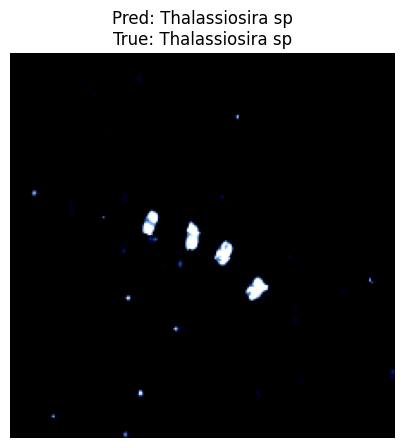

In [42]:
import time
import torch
import matplotlib.pyplot as plt

# Put model in evaluation mode
model.eval()

# Get one image from the test dataset
image, label = test_ds[0]

# Add batch dimension
input_tensor = image.unsqueeze(0).to(DEVICE)

# Warm-up (recommended for GPU)
with torch.no_grad():
    _ = model(input_tensor)

# Measure inference time
start_time = time.perf_counter()

with torch.no_grad():
    output = model(input_tensor)

end_time = time.perf_counter()

# Prediction
pred_class = torch.argmax(output, dim=1).item()

# Inference time
inference_time_ms = (end_time - start_time) * 1000

print(f"Ground Truth : {class_names[label]}")
print(f"Prediction   : {class_names[pred_class]}")
print(f"Inference Time: {inference_time_ms:.3f} ms")

# Display image
img = image.permute(1, 2, 0).cpu().numpy()

# If normalized, uncomment these lines and use your dataset statistics
# mean = [0.485, 0.456, 0.406]
# std = [0.229, 0.224, 0.225]
# img = img * std + mean
# img = img.clip(0, 1)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"Pred: {class_names[pred_class]}\nTrue: {class_names[label]}")
plt.axis("off")
plt.show()

In [35]:
torch.save(model.state_dict(), "original_resnet18_best.pth")

In [36]:
# Calculate total and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 11,181,642
Trainable Parameters : 11,181,642


In [45]:
pip install thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 65.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 

In [46]:
pip install ptflops

Note: you may need to restart the kernel to use updated packages.


In [47]:
pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=ed7dcd86dc5f013a829e06b3743ff969b9bd122f247239f41acd6b5cdebed0d9
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=dc07bbe8ca441dcda35cf2af8cee34f7d414f3f0026126c7d44ce7bd30006864
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath
Note: you may need to restart the kernel to use updated packages.


In [40]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Extract exactly one real test image from your test_loader
# next(iter(test_loader)) returns [batch_of_images, batch_of_labels]
images, labels = next(iter(test_loader))

# Take the first image and add a batch dimension using [0:1] (Shape: 1, 3, 224, 224)
# Move it to the same DEVICE as your model
real_input = images[0:1].to(DEVICE) 

# Ensure model is in evaluation mode
model.eval()

print("--- 1. Using thop (PyTorch-OpCounter) ---")
# Installation: pip install thop
from thop import profile

macs_thop, params_thop = profile(model, inputs=(real_input,), verbose=False)
flops_thop = macs_thop * 2  # 1 MAC ≈ 2 FLOPs

print(f"THOP MACs : {macs_thop:,}")
print(f"THOP FLOPs: {flops_thop:,}")
print(f"THOP GFLOPs: {flops_thop / 1e9:.4f} GFLOPs\n")


print("--- 2. Using ptflops ---")
# Installation: pip install ptflops
from ptflops import get_model_complexity_info

# ptflops expects the input tuple format (channels, height, width) without the batch size
with torch.cuda.device(0) if torch.cuda.is_available() else torch.cpu_amp.autocast():
    macs_pt, params_pt = get_model_complexity_info(
        model, (3, 224, 224), as_strings=False, print_per_layer_stat=False, verbose=False
    )
flops_pt = macs_pt * 2

print(f"ptflops MACs : {macs_pt:,}")
print(f"ptflops FLOPs: {flops_pt:,}")
print(f"ptflops GFLOPs: {flops_pt / 1e9:.4f} GFLOPs\n")


print("--- 3. Using fvcore (Facebook Vision Core) ---")
# Installation: pip install fvcore
from fvcore.nn import FlopCountAnalysis

flop_analyzer = FlopCountAnalysis(model, real_input)
flops_fvcore = flop_analyzer.total()

print(f"fvcore FLOPs/MACs: {flops_fvcore:,}")
print(f"fvcore GFLOPs    : {flops_fvcore / 1e9:.4f} GFLOPs")

--- 1. Using thop (PyTorch-OpCounter) ---
THOP MACs : 1,823,526,912.0
THOP FLOPs: 3,647,053,824.0
THOP GFLOPs: 3.6471 GFLOPs

--- 2. Using ptflops ---


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)


ptflops MACs : 1,824,805,898
ptflops FLOPs: 3,649,611,796
ptflops GFLOPs: 3.6496 GFLOPs

--- 3. Using fvcore (Facebook Vision Core) ---
fvcore FLOPs/MACs: 1,818,558,976
fvcore GFLOPs    : 1.8186 GFLOPs


In [41]:
import time
import torch

# Ensure the model is in evaluation mode and gradients are turned off
model.eval()

# -------------------------------------------------------------
# 1. Prepare 1000 Images from test_loader
# -------------------------------------------------------------
test_images_list = []
total_collected = 0

with torch.no_grad():
    for images, _ in test_loader:
        # Loop through the batch to get individual images
        for i in range(images.size(0)):
            if total_collected >= 1000:
                break
            # Add batch dimension [1, C, H, W] to each individual image
            test_images_list.append(images[i : i + 1])
            total_collected += 1
        if total_collected >= 1000:
            break

print(f"Successfully collected {len(test_images_list)} images for inference testing.\n")

# -------------------------------------------------------------
# 2. Measure CPU Inference Time
# -------------------------------------------------------------
model_cpu = model.to("cpu")
cpu_images = [img.to("cpu") for img in test_images_list]

# Warm-up pass (ensures initialization doesn't skew the results)
with torch.no_grad():
    _ = model_cpu(cpu_images[0])

print("Measuring CPU Inference Time...")
start_time_cpu = time.time()
with torch.no_grad():
    for img in cpu_images:
        _ = model_cpu(img)
end_time_cpu = time.time()

total_cpu_time = end_time_cpu - start_time_cpu
avg_cpu_time = (total_cpu_time / 1000) * 1000  # Convert to milliseconds

print(f"Total CPU Time for 1000 images : {total_cpu_time:.4f} seconds")
print(f"Average CPU Time per image     : {avg_cpu_time:.4f} ms\n")

# -------------------------------------------------------------
# 3. Measure GPU Inference Time (If Available)
# -------------------------------------------------------------
if torch.cuda.is_available():
    model_gpu = model.to("cuda")
    gpu_images = [img.to("cuda") for img in test_images_list]

    # Warm-up pass & synchronization
    with torch.no_grad():
        _ = model_gpu(gpu_images[0])
    torch.cuda.synchronize()

    print("Measuring GPU Inference Time...")
    start_time_gpu = time.time()
    with torch.no_grad():
        for img in gpu_images:
            _ = model_gpu(img)
        torch.cuda.synchronize()  # Force GPU to finish before stopping clock
    end_time_gpu = time.time()

    total_gpu_time = end_time_gpu - start_time_gpu
    avg_gpu_time = (total_gpu_time / 1000) * 1000  # Convert to milliseconds

    print(f"Total GPU Time for 1000 images : {total_gpu_time:.4f} seconds")
    print(f"Average GPU Time per image     : {avg_gpu_time:.4f} ms")
else:
    print("GPU is not available in this environment.")

Successfully collected 1000 images for inference testing.

Measuring CPU Inference Time...
Total CPU Time for 1000 images : 34.9248 seconds
Average CPU Time per image     : 34.9248 ms

Measuring GPU Inference Time...
Total GPU Time for 1000 images : 2.3566 seconds
Average GPU Time per image     : 2.3566 ms


In [42]:
import copy
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from fvcore.nn import FlopCountAnalysis
from thop import profile

# ---------------------------------------------------------------------------
# 1. Helper Functions for Evaluation and Metrics
# ---------------------------------------------------------------------------


def evaluate_accuracy(model, loader, device):
    """Calculates the validation/test accuracy of the model."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return (correct / total) * 100


def get_model_size_mb(model):
    """Saves a temporary state dict to get the true compressed storage footprint."""
    torch.save(model.state_dict(), "temp_pruned.pth")
    size_mb = os.path.getsize("temp_pruned.pth") / (1024 * 1024)
    os.remove("temp_pruned.pth")
    return size_mb


def get_gflops(model, device):
    """Calculates GFLOPs using a single test image."""
    model.eval()
    # Pull one real image from the loader
    images, _ = next(iter(test_loader))
    real_input = images[0:1].to(device)

    # Using thop (1 MAC ≈ 2 FLOPs)
    macs, _ = profile(model, inputs=(real_input,), verbose=False)
    flops = macs * 2
    return flops / 1e9


def fine_tune_model(model, train_loader, criterion, optimizer, device, epochs=5):
    """Fine-tunes the model for a designated number of epochs."""
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


# ---------------------------------------------------------------------------
# 2. Main Pruning Pipeline
# ---------------------------------------------------------------------------

# Setup pruning parameters
sparsity_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Lists to log metrics for plotting
results = {"sparsity": [0.0], "accuracy": [], "size_mb": [], "gflops": []}

# Establish baseline before pruning
print("Calculating baseline metrics...")
results["accuracy"].append(evaluate_accuracy(model, val_loader, DEVICE))
results["size_mb"].append(get_model_size_mb(model))
results["gflops"].append(get_gflops(model, DEVICE))

# Iterate through every pruning ratio
for sparsity in sparsity_ratios:
    print(f"\n--- Pruning Ratio: {int(sparsity * 100)}% ---")

    # Deepcopy the original trained model to prevent compounding across loops
    pruned_model = copy.deepcopy(model).to(DEVICE)

    # Apply L1 Unstructured Pruning to all Conv2d and Linear layers
    for name, module in pruned_model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            torch.nn.utils.prune.l1_unstructured(
                module, name="weight", amount=sparsity
            )

    # Setup optimization for fine-tuning
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(pruned_model.parameters(), lr=1e-5)

    print("Fine-tuning for 5 epochs...")
    fine_tune_model(
        pruned_model, train_loader, criterion, optimizer, DEVICE, epochs=5
    )

    print("Evaluating metrics...")
    acc = evaluate_accuracy(pruned_model, val_loader, DEVICE)
    size = get_model_size_mb(pruned_model)
    gflops = get_gflops(pruned_model, DEVICE)

    # Log metrics
    results["sparsity"].append(sparsity)
    results["accuracy"].append(acc)
    results["size_mb"].append(size)
    results["gflops"].append(gflops)

    print(f"Accuracy: {acc:.2f}% | Size: {size:.2f} MB | GFLOPs: {gflops:.4f}")

    # Remove the pruning hooks to make pruning permanent before dropping the copy
    for name, module in pruned_model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            torch.nn.utils.prune.remove(module, "weight")

# ---------------------------------------------------------------------------
# 3. Plotting Results
# ---------------------------------------------------------------------------
sparsities_pct = [s * 100 for s in results["sparsity"]]

plt.figure(figsize=(18, 5))

# Plot 1: Accuracy vs Sparsity
plt.subplot(1, 3, 1)
plt.plot(
    sparsities_pct, results["accuracy"], marker="o", color="b", linewidth=2
)
plt.title("Accuracy vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Validation Accuracy (%)")
plt.grid(True)

# Plot 2: Model Size vs Sparsity
plt.subplot(1, 3, 2)
plt.plot(
    sparsities_pct, results["size_mb"], marker="s", color="r", linewidth=2
)
plt.title("Model Size vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Model Size (MB)")
plt.grid(True)

# Plot 3: GFLOPs vs Sparsity
plt.subplot(1, 3, 3)
plt.plot(
    sparsities_pct, results["gflops"], marker="^", color="g", linewidth=2
)
plt.title("GFLOPs vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("GFLOPs")
plt.grid(True)

plt.tight_layout()
plt.show()

Calculating baseline metrics...

--- Pruning Ratio: 10% ---


AttributeError: module 'torch.nn.utils' has no attribute 'prune'

Calculating baseline metrics...

--- Global Pruning Ratio: 10% ---
Fine-tuning for 5 epochs...
Evaluating metrics...
Accuracy: 97.14% | Size: 85.36 MB | GFLOPs: 3.6471

--- Global Pruning Ratio: 20% ---
Fine-tuning for 5 epochs...
Evaluating metrics...
Accuracy: 96.95% | Size: 85.36 MB | GFLOPs: 3.6471

--- Global Pruning Ratio: 30% ---
Fine-tuning for 5 epochs...
Evaluating metrics...
Accuracy: 96.86% | Size: 85.36 MB | GFLOPs: 3.6471

--- Global Pruning Ratio: 40% ---
Fine-tuning for 5 epochs...
Evaluating metrics...
Accuracy: 96.86% | Size: 85.36 MB | GFLOPs: 3.6471

--- Global Pruning Ratio: 50% ---
Fine-tuning for 5 epochs...
Evaluating metrics...
Accuracy: 97.05% | Size: 85.36 MB | GFLOPs: 3.6471

--- Global Pruning Ratio: 60% ---
Fine-tuning for 5 epochs...
Evaluating metrics...
Accuracy: 97.14% | Size: 85.36 MB | GFLOPs: 3.6471

--- Global Pruning Ratio: 70% ---
Fine-tuning for 5 epochs...
Evaluating metrics...
Accuracy: 97.14% | Size: 85.36 MB | GFLOPs: 3.6471

--- Global Prun

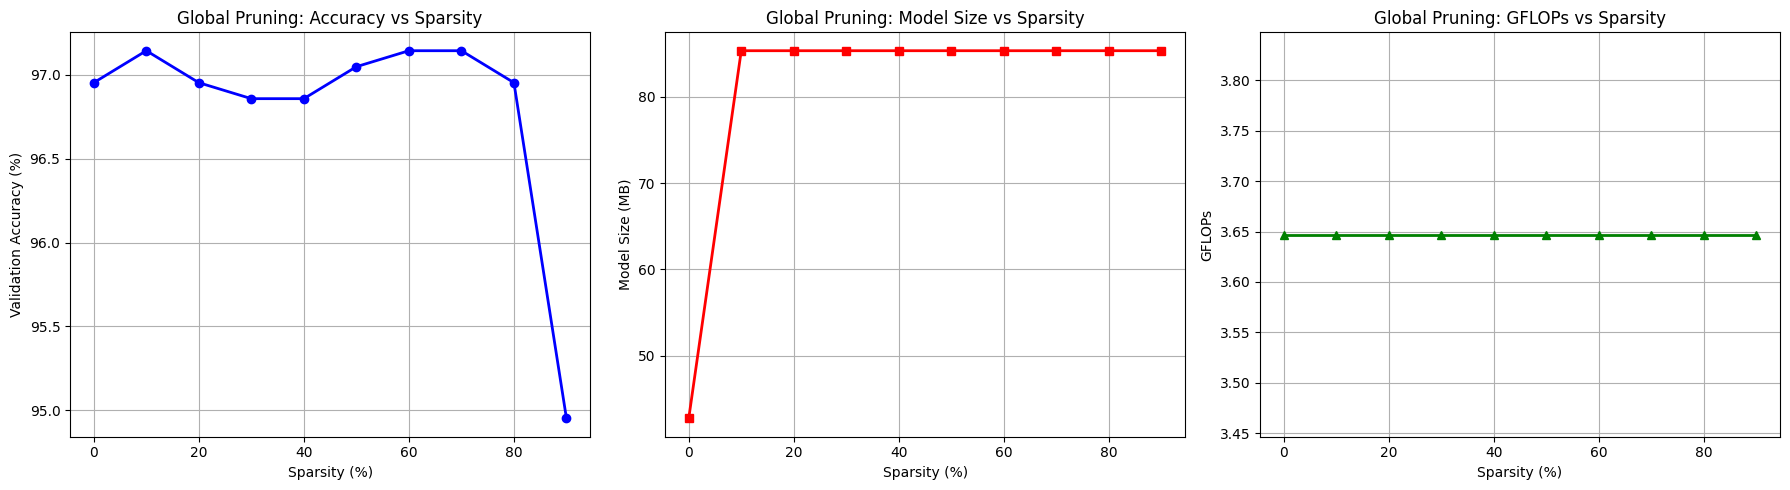

In [50]:
sparsity_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dictionary to hold the tracked statistics
results = {"sparsity": [0.0], "accuracy": [], "size_mb": [], "gflops": []}

# Establish baseline before pruning
print("Calculating baseline metrics...")
results["accuracy"].append(evaluate_accuracy(model, val_loader, DEVICE))
results["size_mb"].append(get_model_size_mb(model))
results["gflops"].append(get_gflops(model, DEVICE))

# Iterate through every pruning ratio
for sparsity in sparsity_ratios:
    print(f"\n--- Global Pruning Ratio: {int(sparsity * 100)}% ---")

    # Clone the original model to keep experiments isolated
    pruned_model = copy.deepcopy(model).to(DEVICE)

    # Gather ALL target parameters across the entire network architecture
    parameters_to_prune = []
    for name, module in pruned_model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            parameters_to_prune.append((module, "weight"))

    # Apply Global Unstructured Pruning across the assembled parameter collection
    torch.nn.utils.prune.global_unstructured(
        parameters_to_prune,
        pruning_method=torch.nn.utils.prune.L1Unstructured,
        amount=sparsity,
    )

    # Setup optimization parameters for fine-tuning
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(pruned_model.parameters(), lr=1e-5)

    print("Fine-tuning for 5 epochs...")
    fine_tune_model(
        pruned_model, train_loader, criterion, optimizer, DEVICE, epochs=5
    )

    print("Evaluating metrics...")
    acc = evaluate_accuracy(pruned_model, val_loader, DEVICE)
    size = get_model_size_mb(pruned_model)
    gflops = get_gflops(pruned_model, DEVICE)

    # Log metrics
    results["sparsity"].append(sparsity)
    results["accuracy"].append(acc)
    results["size_mb"].append(size)
    results["gflops"].append(gflops)

    print(f"Accuracy: {acc:.2f}% | Size: {size:.2f} MB | GFLOPs: {gflops:.4f}")

    # Make the pruning permanent by stripping the mask tensors
    for module, param_name in parameters_to_prune:
        torch.nn.utils.prune.remove(module, param_name)

# ---------------------------------------------------------------------------
# 3. Plotting Results
# ---------------------------------------------------------------------------
sparsities_pct = [s * 100 for s in results["sparsity"]]

plt.figure(figsize=(18, 5))

# Plot 1: Accuracy vs Sparsity
plt.subplot(1, 3, 1)
plt.plot(
    sparsities_pct, results["accuracy"], marker="o", color="b", linewidth=2
)
plt.title("Global Pruning: Accuracy vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Validation Accuracy (%)")
plt.grid(True)

# Plot 2: Model Size vs Sparsity
plt.subplot(1, 3, 2)
plt.plot(
    sparsities_pct, results["size_mb"], marker="s", color="r", linewidth=2
)
plt.title("Global Pruning: Model Size vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Model Size (MB)")
plt.grid(True)

# Plot 3: GFLOPs vs Sparsity
plt.subplot(1, 3, 3)
plt.plot(
    sparsities_pct, results["gflops"], marker="^", color="g", linewidth=2
)
plt.title("Global Pruning: GFLOPs vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("GFLOPs")

plt.grid(True)

plt.tight_layout()
plt.show()

In [1]:
# ---------------------------------------------------------------------------
# 2. Main Structured Pruning Pipeline
# ---------------------------------------------------------------------------

sparsity_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dictionary to hold the tracked statistics
results = {"sparsity": [0.0], "accuracy": [], "size_mb": [], "gflops": []}

# Establish baseline before pruning
print("Calculating baseline metrics...")
results["accuracy"].append(evaluate_accuracy(model, val_loader, DEVICE))
results["size_mb"].append(get_model_size_mb(model))
results["gflops"].append(get_gflops(model, DEVICE))

# Iterate through every pruning ratio
for sparsity in sparsity_ratios:
    print(f"\n--- Structured Pruning Ratio: {int(sparsity * 100)}% ---")

    # Clone the original model to keep experiments isolated
    pruned_model = copy.deepcopy(model).to(DEVICE)

    # Apply L1 structured pruning to all Conv2d layers
    for name, module in pruned_model.named_modules():
        if isinstance(module, nn.Conv2d):
            # amount=sparsity cuts out that % of entire channels
            # dim=0 removes entire output channels (filters)
            # n=1 applies the L1-norm to sort channels by importance
            torch.nn.utils.prune.ln_structured(
                module, name="weight", amount=sparsity, n=1, dim=0
            )

    # Setup optimization parameters for fine-tuning
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(pruned_model.parameters(), lr=1e-5)

    print("Fine-tuning for 5 epochs...")
    fine_tune_model(
        pruned_model, train_loader, criterion, optimizer, DEVICE, epochs=5
    )

    print("Evaluating metrics...")
    acc = evaluate_accuracy(pruned_model, val_loader, DEVICE)
    size = get_model_size_mb(pruned_model)
    gflops = get_gflops(pruned_model, DEVICE)

    # Log metrics
    results["sparsity"].append(sparsity)
    results["accuracy"].append(acc)
    results["size_mb"].append(size)
    results["gflops"].append(gflops)

    print(f"Accuracy: {acc:.2f}% | Size: {size:.2f} MB | GFLOPs: {gflops:.4f}")

    # Make the pruning permanent by removing mask tensors
    for name, module in pruned_model.named_modules():
        if isinstance(module, nn.Conv2d):
            torch.nn.utils.prune.remove(module, "weight")

# ---------------------------------------------------------------------------
# 3. Plotting Results
# ---------------------------------------------------------------------------
sparsities_pct = [s * 100 for s in results["sparsity"]]

plt.figure(figsize=(18, 5))

# Plot 1: Accuracy vs Sparsity
plt.subplot(1, 3, 1)
plt.plot(
    sparsities_pct, results["accuracy"], marker="o", color="b", linewidth=2
)
plt.title("Structured Pruning: Accuracy vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Validation Accuracy (%)")
plt.grid(True)

# Plot 2: Model Size vs Sparsity
plt.subplot(1, 3, 2)
plt.plot(
    sparsities_pct, results["size_mb"], marker="s", color="r", linewidth=2
)
plt.title("Structured Pruning: Model Size vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Model Size (MB)")
plt.grid(True)

# Plot 3: GFLOPs vs Sparsity
plt.subplot(1, 3, 3)
plt.plot(
    sparsities_pct, results["gflops"], marker="^", color="g", linewidth=2
)
plt.title("Structured Pruning: GFLOPs vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("GFLOPs")
plt.grid(True)

plt.tight_layout()
plt.show()

Calculating baseline metrics...


NameError: name 'evaluate_accuracy' is not defined

In [48]:
pip install torch-pruning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [49]:
import copy
import os
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from thop import profile
import torch_pruning as tp  # Installation: pip install torch-pruning

# ---------------------------------------------------------------------------
# 1. Helper Functions for Evaluation and Metrics
# ---------------------------------------------------------------------------


def evaluate_accuracy(model, loader, device):
    """Calculates validation/test accuracy."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return (correct / total) * 100


def get_model_size_mb(model):
    """Saves a temporary state dict to evaluate true physical storage footprint."""
    torch.save(model.state_dict(), "temp_filter_pruned.pth")
    size_mb = os.path.getsize("temp_filter_pruned.pth") / (1024 * 1024)
    os.remove("temp_filter_pruned.pth")
    return size_mb


def get_gflops_and_latency(model, loader, device, num_images=100):
    """Measures physical computational cost (GFLOPs) and true hardware latency."""
    model.eval()
    images, _ = next(iter(loader))
    real_input = images[0:1].to(device)

    # 1. Compute GFLOPs
    macs, _ = profile(model, inputs=(real_input,), verbose=False)
    gflops = (macs * 2) / 1e9

    # 2. Compute Latency (averaged over a subset for speed)
    latency_images = [images[i : i + 1].to(device) for i in range(min(num_images, images.size(0)))]

    # Warmup
    with torch.no_grad():
        _ = model(latency_images[0])
    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()
    with torch.no_grad():
        for img in latency_images:
            _ = model(img)
        if device.type == "cuda":
            torch.cuda.synchronize()
    end_time = time.time()

    avg_latency_ms = ((end_time - start_time) / len(latency_images)) * 1000
    return gflops, avg_latency_ms


def fine_tune_model(model, train_loader, criterion, optimizer, device, epochs=5):
    """Fine-tunes the model for 5 epochs."""
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


# ---------------------------------------------------------------------------
# 2. Main Filter Pruning Pipeline
# ---------------------------------------------------------------------------

sparsity_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dictionary to hold the tracked statistics
results = {
    "sparsity": [0.0],
    "accuracy": [],
    "size_mb": [],
    "gflops": [],
    "latency_ms": [],
}

# Establish baseline before pruning
print("Calculating baseline metrics...")
base_gflops, base_latency = get_gflops_and_latency(model, test_loader, DEVICE)
results["accuracy"].append(evaluate_accuracy(model, val_loader, DEVICE))
results["size_mb"].append(get_model_size_mb(model))
results["gflops"].append(base_gflops)
results["latency_ms"].append(base_latency)

# Iterate through every pruning ratio
for sparsity in sparsity_ratios:
    print(f"\n--- Filter Pruning Ratio: {int(sparsity * 100)}% ---")

    # Clone the original model to keep experiments isolated
    pruned_model = copy.deepcopy(model).to(DEVICE)

    # Setup the TorchPruning dependency graph tool
    # It safely links Conv channels to BatchNorm, ResNet shortcuts, and Linear layers
    example_inputs = torch.randn(1, 3, 224, 224).to(DEVICE)
    imp = tp.importance.MagnitudeImportance(p=1)  # L1 Norm criterion

    ignored_layers = []
    # Ignore the final classifier layer so it retains class outputs
    for m in pruned_model.modules():
        if isinstance(m, nn.Linear) and m.out_features == NUM_CLASSES:
            ignored_layers.append(m)

    pruner = tp.pruner.MetaPruner(
        pruned_model,
        example_inputs,
        importance=imp,
        pruning_ratio=sparsity,  # Removes target % of filters across the graph
        ignored_layers=ignored_layers,
    )

    # Execute the structural modification
    pruner.step()

    # Setup optimization parameters for fine-tuning the smaller architecture
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(pruned_model.parameters(), lr=1e-5)

    print("Fine-tuning the smaller network for 5 epochs...")
    fine_tune_model(
        pruned_model, train_loader, criterion, optimizer, DEVICE, epochs=5
    )

    print("Evaluating metrics...")
    acc = evaluate_accuracy(pruned_model, val_loader, DEVICE)
    size = get_model_size_mb(pruned_model)
    gflops, latency = get_gflops_and_latency(pruned_model, test_loader, DEVICE)

    # Log metrics
    results["sparsity"].append(sparsity)
    results["accuracy"].append(acc)
    results["size_mb"].append(size)
    results["gflops"].append(gflops)
    results["latency_ms"].append(latency)

    print(
        f"Acc: {acc:.2f}% | Size: {size:.2f} MB | GFLOPs: {gflops:.4f} | Latency: {latency:.2f} ms"
    )

# ---------------------------------------------------------------------------
# 3. Plotting Results
# ---------------------------------------------------------------------------
sparsities_pct = [s * 100 for s in results["sparsity"]]

plt.figure(figsize=(20, 4))

# Plot 1: Accuracy vs Sparsity
plt.subplot(1, 4, 1)
plt.plot(
    sparsities_pct, results["accuracy"], marker="o", color="b", linewidth=2
)
plt.title("Accuracy vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.grid(True)

# Plot 2: Model Size vs Sparsity
plt.subplot(1, 4, 2)
plt.plot(
    sparsities_pct, results["size_mb"], marker="s", color="r", linewidth=2
)
plt.title("Model Size vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Size (MB)")
plt.grid(True)

# Plot 3: GFLOPs vs Sparsity
plt.subplot(1, 4, 3)
plt.plot(
    sparsities_pct, results["gflops"], marker="^", color="g", linewidth=2
)
plt.title("GFLOPs vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("GFLOPs")
plt.grid(True)

# Plot 4: Latency vs Sparsity
plt.subplot(1, 4, 4)
plt.plot(
    sparsities_pct, results["latency_ms"], marker="d", color="m", linewidth=2
)
plt.title("Latency vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Latency (ms)")
plt.grid(True)

plt.tight_layout()
plt.show()

Calculating baseline metrics...

--- Filter Pruning Ratio: 10% ---
Fine-tuning the smaller network for 5 epochs...
Evaluating metrics...
Acc: 96.95% | Size: 34.50 MB | GFLOPs: 2.9514 | Latency: 3.83 ms

--- Filter Pruning Ratio: 20% ---
Fine-tuning the smaller network for 5 epochs...
Evaluating metrics...
Acc: 96.19% | Size: 27.27 MB | GFLOPs: 2.3597 | Latency: 3.25 ms

--- Filter Pruning Ratio: 30% ---
Fine-tuning the smaller network for 5 epochs...


KeyboardInterrupt: 

In [48]:
# ---------------------------------------------------------------------------
# 2. Main Filter Pruning Pipeline
# ---------------------------------------------------------------------------

sparsity_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dictionary to hold the tracked statistics
results = {
    "sparsity": [0.0],
    "accuracy": [],
    "size_mb": [],
    "gflops": [],
    "latency_ms": [],
}

# Establish baseline before pruning
print("Calculating baseline metrics...")
base_gflops, base_latency = get_gflops_and_latency(model, test_loader, DEVICE)
results["accuracy"].append(evaluate_accuracy(model, val_loader, DEVICE))
results["size_mb"].append(get_model_size_mb(model))
results["gflops"].append(base_gflops)
results["latency_ms"].append(base_latency)

# Iterate through every pruning ratio
for sparsity in sparsity_ratios:
    pct = int(sparsity * 100)
    print(f"\n--- Filter Pruning Ratio: {pct}% ---")

    # Clone the original model to keep experiments isolated
    pruned_model = copy.deepcopy(model).to(DEVICE)

    # Setup the TorchPruning dependency graph tool
    # It safely links Conv channels to BatchNorm, ResNet shortcuts, and Linear layers
    example_inputs = torch.randn(1, 3, 224, 224).to(DEVICE)
    imp = tp.importance.MagnitudeImportance(p=1)  # L1 Norm criterion

    ignored_layers = []
    # Ignore the final classifier layer so it retains class outputs
    for m in pruned_model.modules():
        if isinstance(m, nn.Linear) and m.out_features == NUM_CLASSES:
            ignored_layers.append(m)

    pruner = tp.pruner.MetaPruner(
        pruned_model,
        example_inputs,
        importance=imp,
        pruning_ratio=sparsity,  # Removes target % of filters across the graph
        ignored_layers=ignored_layers,
    )

    # Execute the structural modification
    pruner.step()

    # Setup optimization parameters for fine-tuning the smaller architecture
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(pruned_model.parameters(), lr=1e-5)

    print("Fine-tuning the smaller network for 5 epochs...")
    fine_tune_model(
        pruned_model, train_loader, criterion, optimizer, DEVICE, epochs=5
    )

    # -----------------------------------------------------------------------
    # Save the Pruned Model
    # -----------------------------------------------------------------------
    # 1. Save Full Model (Architecture + Weights): Best for pruned models where structure changes
    save_path_full = f"resnet18_pruned_{pct}pct.pth"
    torch.save(pruned_model, save_path_full)

    # 2. Save State Dict Only (Optional standard PyTorch weight format)
    save_path_weights = f"resnet18_pruned_{pct}pct_weights.pth"
    torch.save(pruned_model.state_dict(), save_path_weights)

    print(f"Model saved: {save_path_full} and {save_path_weights}")
    # -----------------------------------------------------------------------

    print("Evaluating metrics...")
    acc = evaluate_accuracy(pruned_model, val_loader, DEVICE)
    size = get_model_size_mb(pruned_model)
    gflops, latency = get_gflops_and_latency(pruned_model, test_loader, DEVICE)

    # Log metrics
    results["sparsity"].append(sparsity)
    results["accuracy"].append(acc)
    results["size_mb"].append(size)
    results["gflops"].append(gflops)
    results["latency_ms"].append(latency)

    print(
        f"Acc: {acc:.2f}% | Size: {size:.2f} MB | GFLOPs: {gflops:.4f} | Latency: {latency:.2f} ms"
    )

Calculating baseline metrics...

--- Filter Pruning Ratio: 10% ---
Fine-tuning the smaller network for 5 epochs...
Model saved: resnet18_pruned_10pct.pth and resnet18_pruned_10pct_weights.pth
Evaluating metrics...
Acc: 96.57% | Size: 34.50 MB | GFLOPs: 2.9514 | Latency: 3.82 ms

--- Filter Pruning Ratio: 20% ---
Fine-tuning the smaller network for 5 epochs...
Model saved: resnet18_pruned_20pct.pth and resnet18_pruned_20pct_weights.pth
Evaluating metrics...
Acc: 95.90% | Size: 27.27 MB | GFLOPs: 2.3597 | Latency: 3.25 ms

--- Filter Pruning Ratio: 30% ---
Fine-tuning the smaller network for 5 epochs...
Model saved: resnet18_pruned_30pct.pth and resnet18_pruned_30pct_weights.pth
Evaluating metrics...
Acc: 95.33% | Size: 20.92 MB | GFLOPs: 1.8134 | Latency: 2.86 ms

--- Filter Pruning Ratio: 40% ---
Fine-tuning the smaller network for 5 epochs...
Model saved: resnet18_pruned_40pct.pth and resnet18_pruned_40pct_weights.pth
Evaluating metrics...
Acc: 94.19% | Size: 15.38 MB | GFLOPs: 1.3566

In [ ]:
import torch

# ---------------------------------------------------------------------------
# 1. Configuration & Paths
# ---------------------------------------------------------------------------
model_path = "/kaggle/working/resnet18_pruned_50pct.pth"
onnx_output_path = "/kaggle/working/resnet18_pruned_50pct.onnx"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------------------
# 2. Load the Pruned PyTorch Model
# ---------------------------------------------------------------------------
print(f"Loading pruned model from {model_path}...")
# Load the complete model object (architecture + weights)
model = torch.load(model_path, map_location=device)
model.eval()

# ---------------------------------------------------------------------------
# 3. Create Dummy Input
# ---------------------------------------------------------------------------
# Shape: (Batch Size, Channels, Height, Width) matching ResNet18 input specs
dummy_input = torch.randn(1, 3, 224, 224, device=device)

# ---------------------------------------------------------------------------
# 4. Export to ONNX Format
# ---------------------------------------------------------------------------
print("Exporting model to ONNX...")
torch.onnx.export(
    model,                      # Model being run
    dummy_input,                # Model input (or tuple for multiple inputs)
    onnx_output_path,           # Where to save the model
    export_params=True,         # Store the trained parameter weights inside the model file
    opset_version=14,           # ONNX version support (13 or 14 works great for ONNX Runtime)
    do_constant_folding=True,   # Execute constant folding optimization
    input_names=['input'],      # Input node tensor name
    output_names=['output'],    # Output node tensor name
    dynamic_axes={              # Allows dynamic batch sizes during edge inference
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Successfully exported ONNX model to: {onnx_output_path}")

In [ ]:
import copy
import os
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from thop import profile
import torch_pruning as tp  # Installation: pip install torch-pruning

# ---------------------------------------------------------------------------
# 1. Helper Functions for Evaluation and Metrics
# ---------------------------------------------------------------------------


def evaluate_accuracy(model, loader, device):
    """Calculates validation/test accuracy."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return (correct / total) * 100


def get_model_size_mb(model):
    """Saves a temporary state dict to evaluate true physical storage footprint."""
    torch.save(model.state_dict(), "temp_filter_pruned.pth")
    size_mb = os.path.getsize("temp_filter_pruned.pth") / (1024 * 1024)
    os.remove("temp_filter_pruned.pth")
    return size_mb


def get_gflops_and_latency(model, loader, device, num_images=100):
    """Measures physical computational cost (GFLOPs) and true hardware latency."""
    model.eval()
    images, _ = next(iter(loader))
    real_input = images[0:1].to(device)

    # 1. Compute GFLOPs
    macs, _ = profile(model, inputs=(real_input,), verbose=False)
    gflops = (macs * 2) / 1e9

    # 2. Compute Latency (averaged over a subset for speed)
    latency_images = [images[i : i + 1].to(device) for i in range(min(num_images, images.size(0)))]

    # Warmup
    with torch.no_grad():
        _ = model(latency_images[0])
    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()
    with torch.no_grad():
        for img in latency_images:
            _ = model(img)
        if device.type == "cuda":
            torch.cuda.synchronize()
    end_time = time.time()

    avg_latency_ms = ((end_time - start_time) / len(latency_images)) * 1000
    return gflops, avg_latency_ms


def fine_tune_model(model, train_loader, criterion, optimizer, device, epochs=5):
    """Fine-tunes the model for 5 epochs."""
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


# ---------------------------------------------------------------------------
# 2. Main Filter Pruning Pipeline
# ---------------------------------------------------------------------------

sparsity_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dictionary to hold the tracked statistics
results = {
    "sparsity": [0.0],
    "accuracy": [],
    "size_mb": [],
    "gflops": [],
    "latency_ms": [],
}

# Establish baseline before pruning
print("Calculating baseline metrics...")
base_gflops, base_latency = get_gflops_and_latency(model, test_loader, DEVICE)
results["accuracy"].append(evaluate_accuracy(model, val_loader, DEVICE))
results["size_mb"].append(get_model_size_mb(model))
results["gflops"].append(base_gflops)
results["latency_ms"].append(base_latency)

# Fetch a real sample batch from test_loader to initialize the structural dependencies
test_images, _ = next(iter(test_loader))
# Slice out exactly one real image with the batch dimension intact: [1, C, H, W]
graph_example_input = test_images[0:1].to(DEVICE)

# Iterate through every pruning ratio
for sparsity in sparsity_ratios:
    print(f"\n--- Filter Pruning Ratio: {int(sparsity * 100)}% ---")

    # Clone the original model to keep experiments isolated
    pruned_model = copy.deepcopy(model).to(DEVICE)

    # Setup the TorchPruning dependency graph tool using your real data sample
    imp = tp.importance.MagnitudeImportance(p=1)  # L1 Norm criterion

    ignored_layers = []
    # Ignore the final classifier layer so it retains class outputs
    for m in pruned_model.modules():
        if isinstance(m, nn.Linear) and m.out_features == NUM_CLASSES:
            ignored_layers.append(m)

    pruner = tp.pruner.MetaPruner(
        pruned_model,
        graph_example_input,
        importance=imp,
        pruning_ratio=sparsity,  # Removes target % of filters across the graph
        ignored_layers=ignored_layers,
    )

    # Execute the structural modification
    pruner.step()

    # Setup optimization parameters for fine-tuning the smaller architecture
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(pruned_model.parameters(), lr=1e-5)

    print("Fine-tuning the smaller network for 5 epochs...")
    fine_tune_model(
        pruned_model, train_loader, criterion, optimizer, DEVICE, epochs=5
    )

    print("Evaluating metrics...")
    acc = evaluate_accuracy(pruned_model, val_loader, DEVICE)
    size = get_model_size_mb(pruned_model)
    gflops, latency = get_gflops_and_latency(pruned_model, test_loader, DEVICE)

    # Log metrics
    results["sparsity"].append(sparsity)
    results["accuracy"].append(acc)
    results["size_mb"].append(size)
    results["gflops"].append(gflops)
    results["latency_ms"].append(latency)

    print(
        f"Acc: {acc:.2f}% | Size: {size:.2f} MB | GFLOPs: {gflops:.4f} | Latency: {latency:.2f} ms"
    )

# ---------------------------------------------------------------------------
# 3. Plotting Results
# ---------------------------------------------------------------------------
sparsities_pct = [s * 100 for s in results["sparsity"]]

plt.figure(figsize=(20, 4))

# Plot 1: Accuracy vs Sparsity
plt.subplot(1, 4, 1)
plt.plot(
    sparsities_pct, results["accuracy"], marker="o", color="b", linewidth=2
)
plt.title("Accuracy vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.grid(True)

# Plot 2: Model Size vs Sparsity
plt.subplot(1, 4, 2)
plt.plot(
    sparsities_pct, results["size_mb"], marker="s", color="r", linewidth=2
)
plt.title("Model Size vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Size (MB)")
plt.grid(True)

# Plot 3: GFLOPs vs Sparsity
plt.subplot(1, 4, 3)
plt.plot(
    sparsities_pct, results["gflops"], marker="^", color="g", linewidth=2
)
plt.title("GFLOPs vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("GFLOPs")
plt.grid(True)

# Plot 4: Latency vs Sparsity
plt.subplot(1, 4, 4)
plt.plot(
    sparsities_pct, results["latency_ms"], marker="d", color="m", linewidth=2
)
plt.title("Latency vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Latency (ms)")
plt.grid(True)

plt.tight_layout()
plt.show()

Evaluating metrics...
Acc: 96.38% | Size: 34.50 MB | GFLOPs: 2.9514 | Latency: 3.82 ms

--- Filter Pruning Ratio: 20% ---
Fine-tuning the smaller network for 5 epochs...
Evaluating metrics...
Acc: 95.71% | Size: 27.27 MB | GFLOPs: 2.3597 | Latency: 3.25 ms

--- Filter Pruning Ratio: 30% ---
Fine-tuning the smaller network for 5 epochs...


In [ ]:
pip install torch-pruning


Calculating baseline metrics...


/tmp/ipykernel_58/1562326503.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_fp16):
/tmp/ipykernel_58/1562326503.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_fp16):
/tmp/ipykernel_58/1562326503.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_fp16):



--- Pruning: 10% + Quantization Pipeline ---
Fine-tuning smaller network (5 epochs)...
FP32 -> Acc: 96.86% | Size: 34.50 MB | Latency: 3.82 ms
FP16 -> Acc: 96.95% | Size: 17.27 MB | Latency: 3.77 ms

--- Pruning: 20% + Quantization Pipeline ---
Fine-tuning smaller network (5 epochs)...
FP32 -> Acc: 96.86% | Size: 27.26 MB | Latency: 3.18 ms
FP16 -> Acc: 96.67% | Size: 13.65 MB | Latency: 3.47 ms

--- Pruning: 30% + Quantization Pipeline ---
Fine-tuning smaller network (5 epochs)...
FP32 -> Acc: 96.38% | Size: 20.92 MB | Latency: 2.88 ms
FP16 -> Acc: 96.19% | Size: 10.48 MB | Latency: 2.97 ms

--- Pruning: 40% + Quantization Pipeline ---
Fine-tuning smaller network (5 epochs)...
FP32 -> Acc: 95.71% | Size: 15.38 MB | Latency: 2.49 ms
FP16 -> Acc: 96.00% | Size: 7.71 MB | Latency: 2.94 ms

--- Pruning: 50% + Quantization Pipeline ---
Fine-tuning smaller network (5 epochs)...
FP32 -> Acc: 93.71% | Size: 10.75 MB | Latency: 2.07 ms
FP16 -> Acc: 92.95% | Size: 5.40 MB | Latency: 2.67 ms

-

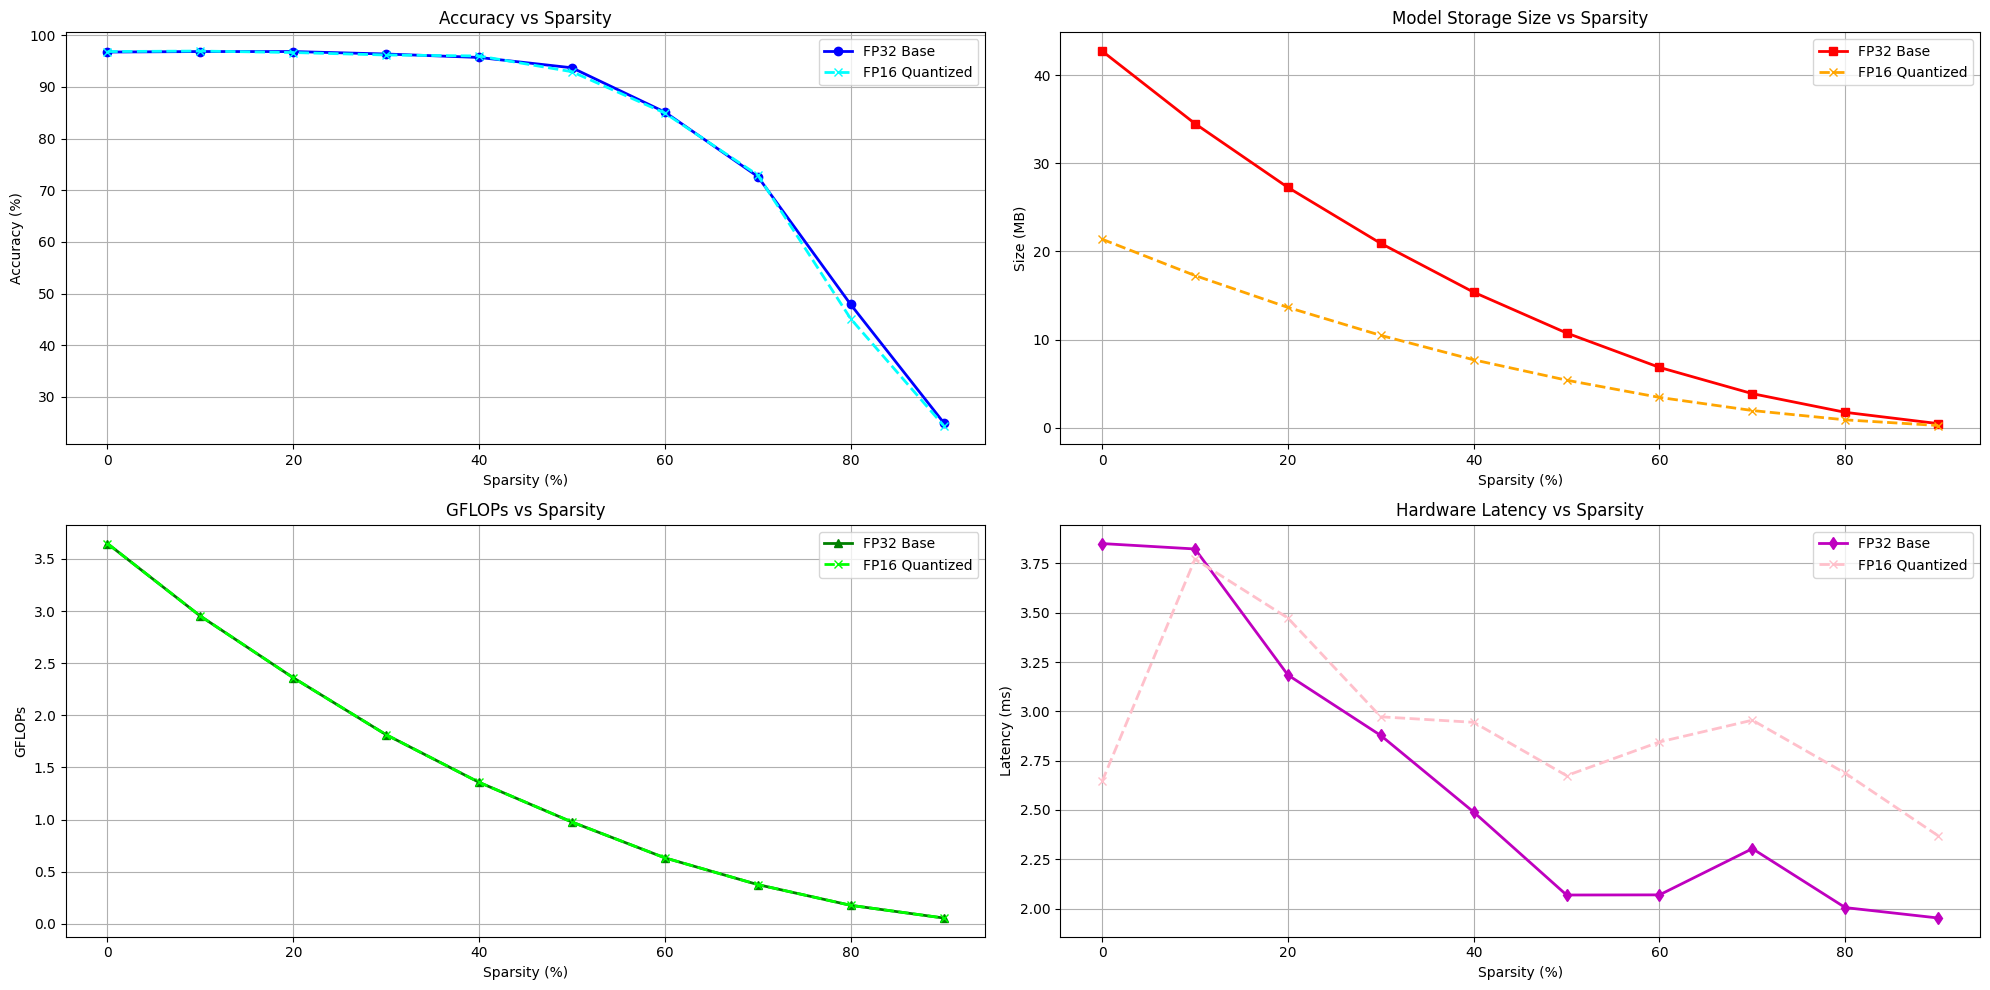

In [55]:
import copy
import os
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from thop import profile
import torch_pruning as tp  # Installation: pip install torch-pruning

# ---------------------------------------------------------------------------
# 1. Helper Functions for Evaluation and Metrics
# ---------------------------------------------------------------------------


def evaluate_accuracy_quantized(model, loader, device, use_fp16=False):
    """Calculates validation/test accuracy with optional FP16 quantization."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        # Enable autocast if using FP16 quantization execution paths
        with torch.cuda.amp.autocast(enabled=use_fp16):
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
    return (correct / total) * 100


def get_model_size_mb(model, use_fp16=False):
    """Saves a temporary state dict to evaluate storage footprint (FP32 vs FP16)."""
    filename = "temp_quantized.pth"
    
    if use_fp16:
        # Cast the parameters to half-precision before saving to disk to simulate true FP16 storage footprint
        half_model = copy.deepcopy(model).half()
        torch.save(half_model.state_dict(), filename)
    else:
        torch.save(model.state_dict(), filename)
        
    size_mb = os.path.getsize(filename) / (1024 * 1024)
    if os.path.exists(filename):
        os.remove(filename)
    return size_mb


def get_gflops_and_latency(model, loader, device, num_images=100, use_fp16=False):
    """Measures physical computational cost (GFLOPs) and true hardware latency (FP32 vs FP16)."""
    model.eval()
    images, _ = next(iter(loader))
    real_input = images[0:1].to(device)

    # 1. Compute GFLOPs
    macs, _ = profile(model, inputs=(real_input,), verbose=False)
    gflops = (macs * 2) / 1e9

    # 2. Compute Latency
    latency_images = [images[i : i + 1].to(device) for i in range(min(num_images, images.size(0)))]

    # Warmup
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=use_fp16):
            _ = model(latency_images[0])
    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()
    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=use_fp16):
            for img in latency_images:
                _ = model(img)
            if device.type == "cuda":
                torch.cuda.synchronize()
    end_time = time.time()

    avg_latency_ms = ((end_time - start_time) / len(latency_images)) * 1000
    return gflops, avg_latency_ms


def fine_tune_model(model, train_loader, criterion, optimizer, device, epochs=5):
    """Fine-tunes the FP32 model for 5 epochs before quantization."""
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


# ---------------------------------------------------------------------------
# 2. Main Filter Pruning & Quantization Pipeline
# ---------------------------------------------------------------------------

sparsity_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dictionary to track statistics for BOTH configurations
results = {
    "sparsity": [0.0],
    # FP32 Baselines
    "acc_fp32": [], "size_fp32": [], "gflops_fp32": [], "latency_fp32": [],
    # Quantized FP16
    "acc_fp16": [], "size_fp16": [], "gflops_fp16": [], "latency_fp16": []
}

# Pull structural sample input from the test_loader
test_images, _ = next(iter(test_loader))
graph_real_input = test_images[0:1].to(DEVICE)

# 2a. Gather baseline metrics before modifying anything
print("Calculating baseline metrics...")
base_gflops_32, base_lat_32 = get_gflops_and_latency(model, test_loader, DEVICE, use_fp16=False)
base_gflops_16, base_lat_16 = get_gflops_and_latency(model, test_loader, DEVICE, use_fp16=True)

results["acc_fp32"].append(evaluate_accuracy_quantized(model, val_loader, DEVICE, use_fp16=False))
results["size_fp32"].append(get_model_size_mb(model, use_fp16=False))
results["gflops_fp32"].append(base_gflops_32)
results["latency_fp32"].append(base_lat_32)

results["acc_fp16"].append(evaluate_accuracy_quantized(model, val_loader, DEVICE, use_fp16=True))
results["size_fp16"].append(get_model_size_mb(model, use_fp16=True))
results["gflops_fp16"].append(base_gflops_16)
results["latency_fp16"].append(base_lat_16)

# 2b. Iterate through every pruning ratio
for sparsity in sparsity_ratios:
    print(f"\n--- Pruning: {int(sparsity * 100)}% + Quantization Pipeline ---")

    # Clone original model
    pruned_model = copy.deepcopy(model).to(DEVICE)
    imp = tp.importance.MagnitudeImportance(p=1)

    ignored_layers = []
    for m in pruned_model.modules():
        if isinstance(m, nn.Linear) and m.out_features == NUM_CLASSES:
            ignored_layers.append(m)

    # Initialize TorchPruning graph
    pruner = tp.pruner.MetaPruner(
        pruned_model,
        graph_real_input,
        importance=imp,
        pruning_ratio=sparsity,
        ignored_layers=ignored_layers,
    )
    pruner.step()

    # Fine-tune the smaller network in standard FP32 format
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(pruned_model.parameters(), lr=1e-5)
    print("Fine-tuning smaller network (5 epochs)...")
    fine_tune_model(pruned_model, train_loader, criterion, optimizer, DEVICE, epochs=5)

    # --- Evaluate FP32 configuration ---
    acc_32 = evaluate_accuracy_quantized(pruned_model, val_loader, DEVICE, use_fp16=False)
    size_32 = get_model_size_mb(pruned_model, use_fp16=False)
    gflops_32, lat_32 = get_gflops_and_latency(pruned_model, test_loader, DEVICE, use_fp16=False)

    # --- Evaluate FP16 Quantized configuration ---
    acc_16 = evaluate_accuracy_quantized(pruned_model, val_loader, DEVICE, use_fp16=True)
    size_16 = get_model_size_mb(pruned_model, use_fp16=True)
    gflops_16, lat_16 = get_gflops_and_latency(pruned_model, test_loader, DEVICE, use_fp16=True)

    # Log metrics
    results["sparsity"].append(sparsity)
    results["acc_fp32"].append(acc_32)
    results["size_fp32"].append(size_32)
    results["gflops_fp32"].append(gflops_32)
    results["latency_fp32"].append(lat_32)

    results["acc_fp16"].append(acc_16)
    results["size_fp16"].append(size_16)
    results["gflops_fp16"].append(gflops_16)
    results["latency_fp16"].append(lat_16)

    print(f"FP32 -> Acc: {acc_32:.2f}% | Size: {size_32:.2f} MB | Latency: {lat_32:.2f} ms")
    print(f"FP16 -> Acc: {acc_16:.2f}% | Size: {size_16:.2f} MB | Latency: {lat_16:.2f} ms")

# ---------------------------------------------------------------------------
# 3. Plotting Results (Comparing FP32 vs FP16 Quantized)
# ---------------------------------------------------------------------------
sparsities_pct = [s * 100 for s in results["sparsity"]]

plt.figure(figsize=(20, 10))

# Plot 1: Accuracy Comparison
plt.subplot(2, 2, 1)
plt.plot(sparsities_pct, results["acc_fp32"], marker="o", color="b", label="FP32 Base", linewidth=2)
plt.plot(sparsities_pct, results["acc_fp16"], marker="x", color="cyan", linestyle="--", label="FP16 Quantized", linewidth=2)
plt.title("Accuracy vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# Plot 2: Model Size Comparison (Visualizes the ~50% drop)
plt.subplot(2, 2, 2)
plt.plot(sparsities_pct, results["size_fp32"], marker="s", color="r", label="FP32 Base", linewidth=2)
plt.plot(sparsities_pct, results["size_fp16"], marker="x", color="orange", linestyle="--", label="FP16 Quantized", linewidth=2)
plt.title("Model Storage Size vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Size (MB)")
plt.legend()
plt.grid(True)

# Plot 3: GFLOPs Comparison
plt.subplot(2, 2, 3)
plt.plot(sparsities_pct, results["gflops_fp32"], marker="^", color="g", label="FP32 Base", linewidth=2)
plt.plot(sparsities_pct, results["gflops_fp16"], marker="x", color="lime", linestyle="--", label="FP16 Quantized", linewidth=2)
plt.title("GFLOPs vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("GFLOPs")
plt.legend()
plt.grid(True)

# Plot 4: Latency Comparison
plt.subplot(2, 2, 4)
plt.plot(sparsities_pct, results["latency_fp32"], marker="d", color="m", label="FP32 Base", linewidth=2)
plt.plot(sparsities_pct, results["latency_fp16"], marker="x", color="pink", linestyle="--", label="FP16 Quantized", linewidth=2)
plt.title("Hardware Latency vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Latency (ms)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
pip install torch-pruning

Note: you may need to restart the kernel to use updated packages.


Calculating baseline metrics...


/tmp/ipykernel_58/3297853269.py:109: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_baseline = torch.quantization.quantize_dynamic(



--- Pruning: 10% + Dynamic INT8 Pipeline ---
Fine-tuning smaller network (5 epochs)...


/tmp/ipykernel_58/3297853269.py:161: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


FP32 -> Acc: 96.76% | Size: 34.50 MB | Latency: 3.82 ms
INT8 -> Acc: 96.95% | Size: 34.49 MB | Latency: 29.70 ms

--- Pruning: 20% + Dynamic INT8 Pipeline ---
Fine-tuning smaller network (5 epochs)...
FP32 -> Acc: 96.00% | Size: 27.27 MB | Latency: 3.24 ms
INT8 -> Acc: 96.48% | Size: 27.25 MB | Latency: 27.00 ms

--- Pruning: 30% + Dynamic INT8 Pipeline ---
Fine-tuning smaller network (5 epochs)...
FP32 -> Acc: 96.00% | Size: 20.92 MB | Latency: 2.87 ms
INT8 -> Acc: 96.29% | Size: 20.91 MB | Latency: 21.92 ms

--- Pruning: 40% + Dynamic INT8 Pipeline ---
Fine-tuning smaller network (5 epochs)...
FP32 -> Acc: 95.24% | Size: 15.38 MB | Latency: 2.49 ms
INT8 -> Acc: 96.10% | Size: 15.37 MB | Latency: 22.02 ms

--- Pruning: 50% + Dynamic INT8 Pipeline ---
Fine-tuning smaller network (5 epochs)...
FP32 -> Acc: 92.95% | Size: 10.75 MB | Latency: 2.08 ms
INT8 -> Acc: 91.52% | Size: 10.74 MB | Latency: 12.33 ms

--- Pruning: 60% + Dynamic INT8 Pipeline ---
Fine-tuning smaller network (5 epochs

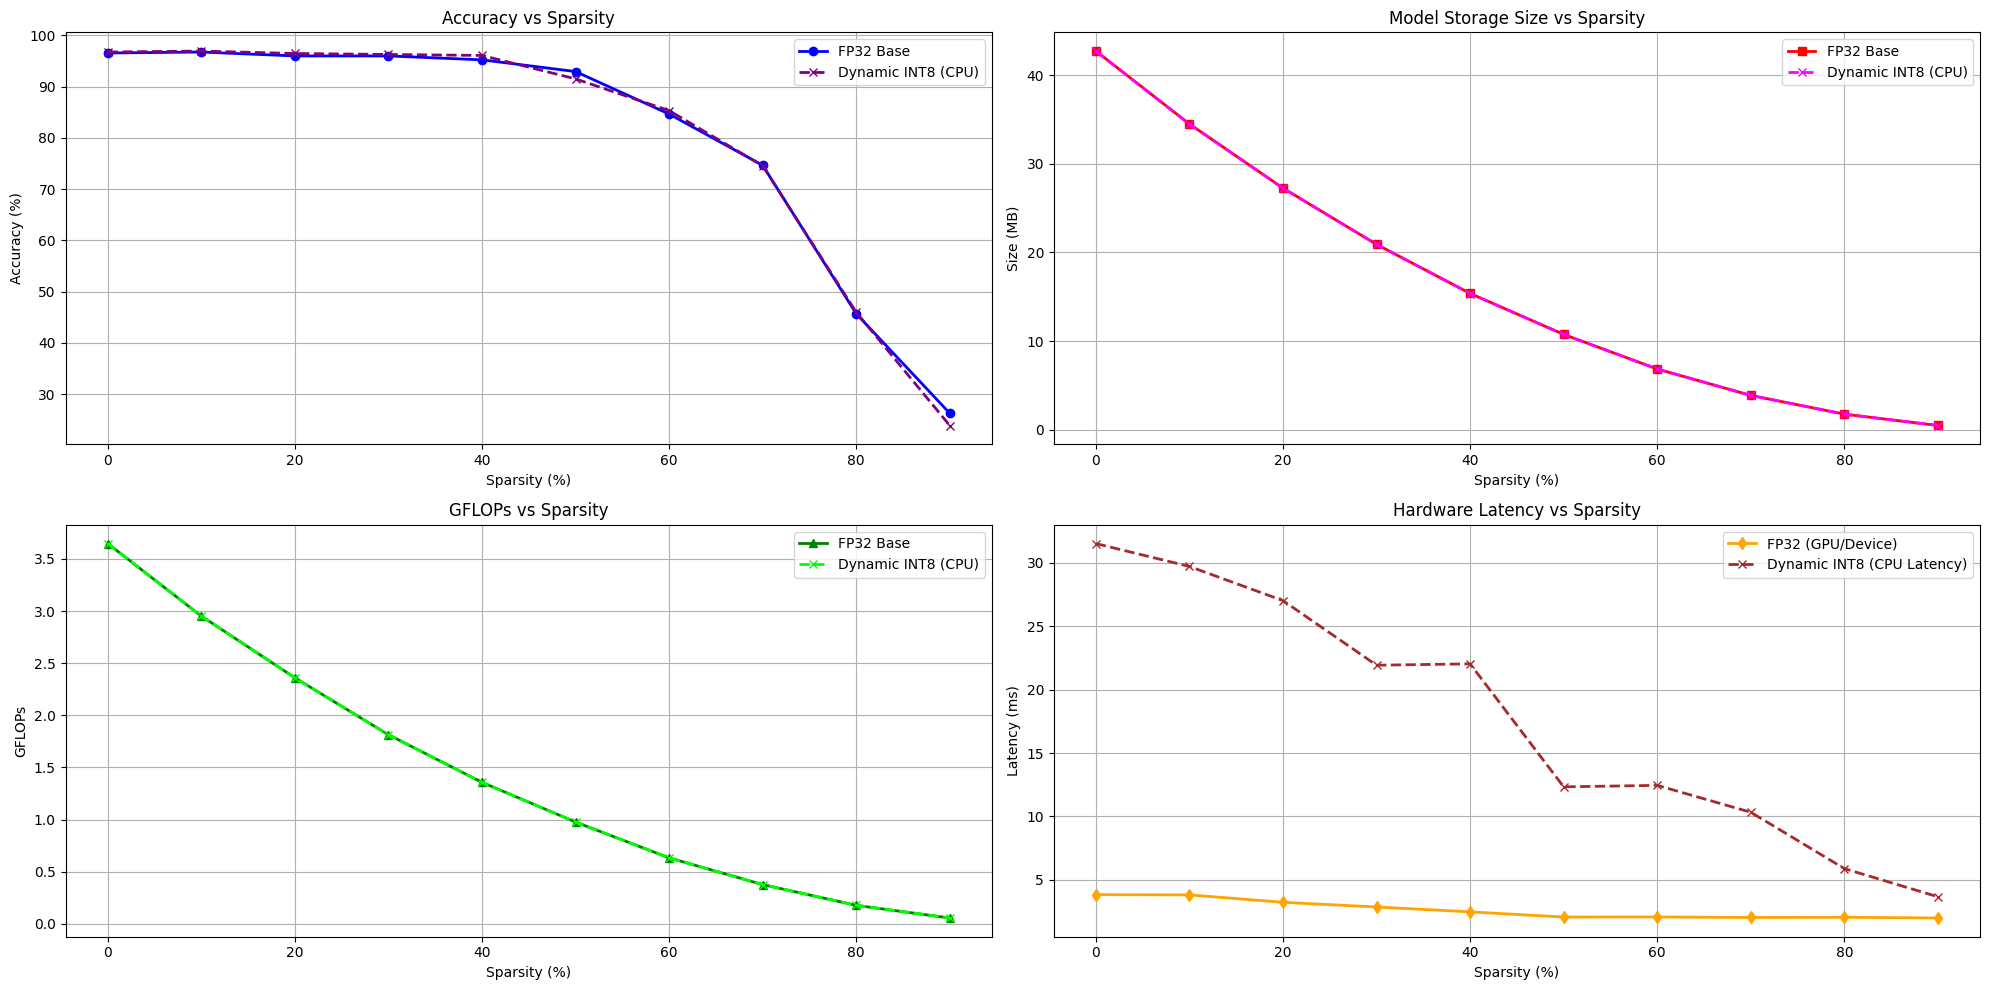

In [56]:
import copy
import os
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from thop import profile
import torch_pruning as tp  # Installation: pip install torch-pruning

# ---------------------------------------------------------------------------
# 1. Helper Functions for Evaluation and Metrics
# ---------------------------------------------------------------------------


def evaluate_accuracy(model, loader, device):
    """Calculates validation/test accuracy. Handles both CPU and GPU models."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return (correct / total) * 100


def get_model_size_mb(model):
    """Saves a temporary state dict to evaluate true physical storage footprint."""
    filename = "temp_quantized_int8.pth"
    torch.save(model.state_dict(), filename)
    size_mb = os.path.getsize(filename) / (1024 * 1024)
    if os.path.exists(filename):
        os.remove(filename)
    return size_mb


def get_gflops_and_latency(model, loader, device, num_images=100):
    """Measures physical computational cost (GFLOPs) and hardware latency."""
    model.eval()
    images, _ = next(iter(loader))
    real_input = images[0:1].to(device)

    # 1. Compute GFLOPs (computed via FP32 layout as structural indicator)
    try:
        macs, _ = profile(model, inputs=(real_input,), verbose=False)
        gflops = (macs * 2) / 1e9
    except Exception:
        gflops = 0.0  # Quantized models sometimes throw profiling hooks errors; fall back cleanly

    # 2. Compute Latency
    latency_images = [images[i : i + 1].to(device) for i in range(min(num_images, images.size(0)))]

    # Warmup
    with torch.no_grad():
        _ = model(latency_images[0])
    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()
    with torch.no_grad():
        for img in latency_images:
            _ = model(img)
        if device.type == "cuda":
            torch.cuda.synchronize()
    end_time = time.time()

    avg_latency_ms = ((end_time - start_time) / len(latency_images)) * 1000
    return gflops, avg_latency_ms


def fine_tune_model(model, train_loader, criterion, optimizer, device, epochs=5):
    """Fine-tunes the FP32 model for 5 epochs before quantization."""
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


# ---------------------------------------------------------------------------
# 2. Main Filter Pruning & Dynamic INT8 Quantization Pipeline
# ---------------------------------------------------------------------------

sparsity_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results = {
    "sparsity": [0.0],
    # FP32 Baselines
    "acc_fp32": [], "size_fp32": [], "gflops_fp32": [], "latency_fp32": [],
    # Dynamic INT8 Quantized
    "acc_int8": [], "size_int8": [], "gflops_int8": [], "latency_int8": []
}

# Pull structural sample input from test_loader
test_images, _ = next(iter(test_loader))
graph_real_input = test_images[0:1].to(DEVICE)

print("Calculating baseline metrics...")
# Note: PyTorch Dynamic Quantization is natively supported primarily on CPU targets
# We create a CPU copy specifically to observe the true INT8 performance drop
model_cpu = copy.deepcopy(model).to("cpu")
quantized_baseline = torch.quantization.quantize_dynamic(
    model_cpu, {nn.Linear}, dtype=torch.qint8
)

base_gflops_32, base_lat_32 = get_gflops_and_latency(model, test_loader, DEVICE)
base_gflops_8, base_lat_8 = get_gflops_and_latency(quantized_baseline, test_loader, torch.device("cpu"))

results["acc_fp32"].append(evaluate_accuracy(model, val_loader, DEVICE))
results["size_fp32"].append(get_model_size_mb(model))
results["gflops_fp32"].append(base_gflops_32)
results["latency_fp32"].append(base_lat_32)

results["acc_int8"].append(evaluate_accuracy(quantized_baseline, val_loader, torch.device("cpu")))
results["size_int8"].append(get_model_size_mb(quantized_baseline))
results["gflops_int8"].append(base_gflops_8)
results["latency_int8"].append(base_lat_8)

# Loop through pruning configurations
for sparsity in sparsity_ratios:
    print(f"\n--- Pruning: {int(sparsity * 100)}% + Dynamic INT8 Pipeline ---")

    # 1. Prune structural filters in FP32 (on GPU/Device)
    pruned_model = copy.deepcopy(model).to(DEVICE)
    imp = tp.importance.MagnitudeImportance(p=1)

    ignored_layers = []
    for m in pruned_model.modules():
        if isinstance(m, nn.Linear) and m.out_features == NUM_CLASSES:
            ignored_layers.append(m)

    pruner = tp.pruner.MetaPruner(
        pruned_model,
        graph_real_input,
        importance=imp,
        pruning_ratio=sparsity,
        ignored_layers=ignored_layers,
    )
    pruner.step()

    # 2. Fine-tune the pruned model
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(pruned_model.parameters(), lr=1e-5)
    print("Fine-tuning smaller network (5 epochs)...")
    fine_tune_model(pruned_model, train_loader, criterion, optimizer, DEVICE, epochs=5)

    # --- Evaluate FP32 configuration ---
    acc_32 = evaluate_accuracy(pruned_model, val_loader, DEVICE)
    size_32 = get_model_size_mb(pruned_model)
    gflops_32, lat_32 = get_gflops_and_latency(pruned_model, test_loader, DEVICE)

    # --- 3. Apply Dynamic INT8 Quantization (1-line modification) ---
    pruned_cpu = copy.deepcopy(pruned_model).to("cpu")
    quantized_model = torch.quantization.quantize_dynamic(
        pruned_cpu, {nn.Linear}, dtype=torch.qint8
    )

    # --- Evaluate Quantized INT8 configuration ---
    acc_8 = evaluate_accuracy(quantized_model, val_loader, torch.device("cpu"))
    size_8 = get_model_size_mb(quantized_model)
    gflops_8, lat_8 = get_gflops_and_latency(quantized_model, test_loader, torch.device("cpu"))

    # Log metrics
    results["sparsity"].append(sparsity)
    results["acc_fp32"].append(acc_32)
    results["size_fp32"].append(size_32)
    results["gflops_fp32"].append(gflops_32)
    results["latency_fp32"].append(lat_32)

    results["acc_int8"].append(acc_8)
    results["size_int8"].append(size_8)
    results["gflops_int8"].append(gflops_8)
    results["latency_int8"].append(lat_8)

    print(f"FP32 -> Acc: {acc_32:.2f}% | Size: {size_32:.2f} MB | Latency: {lat_32:.2f} ms")
    print(f"INT8 -> Acc: {acc_8:.2f}% | Size: {size_8:.2f} MB | Latency: {lat_8:.2f} ms")

# ---------------------------------------------------------------------------
# 3. Plotting Results (Comparing FP32 vs Dynamic INT8)
# ---------------------------------------------------------------------------
sparsities_pct = [s * 100 for s in results["sparsity"]]

plt.figure(figsize=(20, 10))

# Plot 1: Accuracy Comparison
plt.subplot(2, 2, 1)
plt.plot(sparsities_pct, results["acc_fp32"], marker="o", color="b", label="FP32 Base", linewidth=2)
plt.plot(sparsities_pct, results["acc_int8"], marker="x", color="purple", linestyle="--", label="Dynamic INT8 (CPU)", linewidth=2)
plt.title("Accuracy vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# Plot 2: Model Size Comparison
plt.subplot(2, 2, 2)
plt.plot(sparsities_pct, results["size_fp32"], marker="s", color="r", label="FP32 Base", linewidth=2)
plt.plot(sparsities_pct, results["size_int8"], marker="x", color="magenta", linestyle="--", label="Dynamic INT8 (CPU)", linewidth=2)
plt.title("Model Storage Size vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Size (MB)")
plt.legend()
plt.grid(True)

# Plot 3: GFLOPs Comparison
plt.subplot(2, 2, 3)
plt.plot(sparsities_pct, results["gflops_fp32"], marker="^", color="g", label="FP32 Base", linewidth=2)
plt.plot(sparsities_pct, results["gflops_int8"], marker="x", color="lime", linestyle="--", label="Dynamic INT8 (CPU)", linewidth=2)
plt.title("GFLOPs vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("GFLOPs")
plt.legend()
plt.grid(True)

# Plot 4: Latency Comparison
plt.subplot(2, 2, 4)
plt.plot(sparsities_pct, results["latency_fp32"], marker="d", color="orange", label="FP32 (GPU/Device)", linewidth=2)
plt.plot(sparsities_pct, results["latency_int8"], marker="x", color="brown", linestyle="--", label="Dynamic INT8 (CPU Latency)", linewidth=2)
plt.title("Hardware Latency vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Latency (ms)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [50]:
import torch

# ---------------------------------------------------------------------------
# 1. Configuration & Paths
# ---------------------------------------------------------------------------
model_path = "/kaggle/working/resnet18_pruned_50pct.pth"
onnx_output_path = "/kaggle/working/resnet18_pruned_50pct.onnx"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------------------
# 2. Load the Pruned PyTorch Model
# ---------------------------------------------------------------------------
print(f"Loading pruned model from {model_path}...")
# Load the complete model object (architecture + weights)
model = torch.load(model_path, map_location=device)
model.eval()

# ---------------------------------------------------------------------------
# 3. Create Dummy Input
# ---------------------------------------------------------------------------
# Shape: (Batch Size, Channels, Height, Width) matching ResNet18 input specs
dummy_input = torch.randn(1, 3, 224, 224, device=device)

# ---------------------------------------------------------------------------
# 4. Export to ONNX Format
# ---------------------------------------------------------------------------
print("Exporting model to ONNX...")
torch.onnx.export(
    model,                      # Model being run
    dummy_input,                # Model input (or tuple for multiple inputs)
    onnx_output_path,           # Where to save the model
    export_params=True,         # Store the trained parameter weights inside the model file
    opset_version=14,           # ONNX version support (13 or 14 works great for ONNX Runtime)
    do_constant_folding=True,   # Execute constant folding optimization
    input_names=['input'],      # Input node tensor name
    output_names=['output'],    # Output node tensor name
    dynamic_axes={              # Allows dynamic batch sizes during edge inference
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Successfully exported ONNX model to: {onnx_output_path}")

Loading pruned model from /kaggle/working/resnet18_pruned_50pct.pth...


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torchvision.models.resnet.ResNet was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torchvision.models.resnet.ResNet])` or the `torch.serialization.safe_globals([torchvision.models.resnet.ResNet])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load 

In [52]:
import torch

# ---------------------------------------------------------------------------
# 1. Configuration & Paths
# ---------------------------------------------------------------------------
model_path = "/kaggle/working/resnet18_pruned_50pct.pth"
onnx_output_path = "/kaggle/working/resnet18_pruned_50pct.onnx"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------------------
# 2. Load the Pruned PyTorch Model
# ---------------------------------------------------------------------------
print(f"Loading pruned model from {model_path}...")
# Added weights_only=False to allow loading full model architecture in PyTorch 2.6+
model = torch.load(model_path, map_location=device, weights_only=False)
model.eval()

# ---------------------------------------------------------------------------
# 3. Create Dummy Input
# ---------------------------------------------------------------------------
dummy_input = torch.randn(1, 3, 224, 224, device=device)

# ---------------------------------------------------------------------------
# 4. Export to ONNX Format
# ---------------------------------------------------------------------------
print("Exporting model to ONNX...")
torch.onnx.export(
    model,
    dummy_input,
    onnx_output_path,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Successfully exported ONNX model to: {onnx_output_path}")

Loading pruned model from /kaggle/working/resnet18_pruned_50pct.pth...


AttributeError: 'ResNet' object has no attribute 'start_flops_count'

In [53]:
import torch

model_path = "/kaggle/working/resnet18_pruned_50pct.pth"
onnx_output_path = "/kaggle/working/resnet18_pruned_50pct.onnx"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Patch for thop / ptflops dynamic attribute issue ---
class FlopCountCleanupUnpickler(torch.serialization._weights_only_unpickler if hasattr(torch.serialization, '_weights_only_unpickler') else object):
    pass

# Safe loading by stripping out missing dynamically attached functions
try:
    model = torch.load(model_path, map_location=device, weights_only=False)
except AttributeError:
    # If loading fails due to missing thop/flops attributes, define dummy attributes
    import torchvision.models.resnet as resnet
    resnet.ResNet.start_flops_count = None
    resnet.ResNet.stop_flops_count = None
    resnet.ResNet.reset_flops_count = None
    resnet.ResNet.compute_average_flops_cost = None
    
    # Retry loading
    model = torch.load(model_path, map_location=device, weights_only=False)
    
    # Remove dummy attributes
    delattr(resnet.ResNet, 'start_flops_count')
    delattr(resnet.ResNet, 'stop_flops_count')
    delattr(resnet.ResNet, 'reset_flops_count')
    delattr(resnet.ResNet, 'compute_average_flops_cost')

model.eval()
print("Model loaded successfully!")

TypeError: module() takes at most 2 arguments (3 given)

In [56]:
import torch
import torchvision.models.resnet as resnet

# 1. Paths & Device Configuration
model_path = "/kaggle/working/resnet18_pruned_50pct.pth"
onnx_output_path = "/kaggle/working/resnet18_pruned_50pct.onnx"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Patch ResNet class dynamically to handle THOP/ptflops artifacts during unpickling
flop_attrs = [
    'start_flops_count', 
    'stop_flops_count', 
    'reset_flops_count', 
    'compute_average_flops_cost',
    '__batch_counter__'
]

# Temporarily assign dummy properties to ResNet class
for attr in flop_attrs:
    setattr(resnet.ResNet, attr, None)

print(f"Loading pruned model from {model_path}...")
model = torch.load(model_path, map_location=device, weights_only=False)

# Clean up dummy properties from the loaded model class/instance
for attr in flop_attrs:
    if hasattr(resnet.ResNet, attr):
        delattr(resnet.ResNet, attr)
    if hasattr(model, attr):
        delattr(model, attr)

model.eval()
print("Model loaded successfully!")

# 3. Create Dummy Input
dummy_input = torch.randn(1, 3, 224, 224, device=device)

# 4. Export to ONNX Format
print("Exporting model to ONNX...")
torch.onnx.export(
    model,
    dummy_input,
    onnx_output_path,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Successfully exported ONNX model to: {onnx_output_path}")

Loading pruned model from /kaggle/working/resnet18_pruned_50pct.pth...
Model loaded successfully!
Exporting model to ONNX...


/tmp/ipykernel_58/576171521.py:40: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0729 07:59:42.244000 58 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0729 07:59:43.368000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, al

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).
Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Successfully exported ONNX model to: /kaggle/working/resnet18_pruned_50pct.onnx


In [55]:
!pip install -q onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 11.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 11.7 MB/s eta 0:00:00


In [51]:
import copy
import os
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune  # <--- Explicitly import the prune module
from thop import profile

# ---------------------------------------------------------------------------
# 1. Helper Functions
# ---------------------------------------------------------------------------

def evaluate_accuracy(model, loader, device):
    """Calculates validation/test accuracy."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return (correct / total) * 100


def get_model_size_mb(model):
    """Saves a temporary state dict to evaluate physical storage footprint."""
    torch.save(model.state_dict(), "temp_oneshot_pruned.pth")
    size_mb = os.path.getsize("temp_oneshot_pruned.pth") / (1024 * 1024)
    if os.path.exists("temp_oneshot_pruned.pth"):
        os.remove("temp_oneshot_pruned.pth")
    return size_mb


def fine_tune_model(model, train_loader, criterion, optimizer, device, epochs=5):
    """Fine-tunes the pruned model."""
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


# ---------------------------------------------------------------------------
# 2. One-Shot Pruning Pipeline
# ---------------------------------------------------------------------------

# Set your desired target sparsity (e.g., 50% of weights pruned)
TARGET_SPARSITY = 0.50
FINE_TUNE_EPOCHS = 5

print("==================================================")
print("           ONE-SHOT PRUNING PIPELINE              ")
print("==================================================")

# Create a copy of the pre-trained model
pruned_model = copy.deepcopy(model).to(DEVICE)

# 1. Baseline Evaluation
print("\n--- 1. Pre-Pruning Baseline ---")
base_acc = evaluate_accuracy(pruned_model, val_loader, DEVICE)
base_size = get_model_size_mb(pruned_model)
print(f"Baseline Accuracy : {base_acc:.2f}%")
print(f"Baseline Model Size: {base_size:.2f} MB")

# 2. Apply One-Shot L1 Unstructured Pruning across Conv2d and Linear layers
print(f"\n--- 2. Executing One-Shot Pruning ({int(TARGET_SPARSITY * 100)}% Sparsity) ---")
for name, module in pruned_model.named_modules():
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
        prune.l1_unstructured(
            module, name="weight", amount=TARGET_SPARSITY
        )

# Make the zeroed weights permanent and remove pruning masks
for name, module in pruned_model.named_modules():
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
        prune.remove(module, "weight")

pruned_acc = evaluate_accuracy(pruned_model, val_loader, DEVICE)
print(f"Accuracy immediately after pruning (before fine-tuning): {pruned_acc:.2f}%")

# 3. Fine-Tuning Step
print(f"\n--- 3. Fine-tuning Pruned Model ({FINE_TUNE_EPOCHS} Epochs) ---")
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(pruned_model.parameters(), lr=1e-5)

fine_tune_model(
    pruned_model, train_loader, criterion, optimizer, DEVICE, epochs=FINE_TUNE_EPOCHS
)

# 4. Final Evaluation
final_acc = evaluate_accuracy(pruned_model, val_loader, DEVICE)
final_size = get_model_size_mb(pruned_model)

print("\n==================================================")
print("                   FINAL RESULTS                  ")
print("==================================================")
print(f"Original Accuracy : {base_acc:.2f}%")
print(f"Post-FT Accuracy  : {final_acc:.2f}% (Accuracy Recovery: {final_acc - pruned_acc:+.2f}%)")
print(f"Model Size        : {final_size:.2f} MB")
print("==================================================")

# 5. Save the One-Shot Pruned Model
save_path = f"resnet18_oneshot_pruned_{int(TARGET_SPARSITY * 100)}pct.pth"
torch.save(pruned_model, save_path)
print(f"Saved One-Shot Pruned Model to: {save_path}")

           ONE-SHOT PRUNING PIPELINE              

--- 1. Pre-Pruning Baseline ---
Baseline Accuracy : 96.95%
Baseline Model Size: 42.74 MB

--- 2. Executing One-Shot Pruning (50% Sparsity) ---
Accuracy immediately after pruning (before fine-tuning): 92.19%

--- 3. Fine-tuning Pruned Model (5 Epochs) ---

                   FINAL RESULTS                  
Original Accuracy : 96.95%
Post-FT Accuracy  : 96.95% (Accuracy Recovery: +4.76%)
Model Size        : 42.74 MB
Saved One-Shot Pruned Model to: resnet18_oneshot_pruned_50pct.pth


         ITERATIVE PRUNING PIPELINE               
Baseline Accuracy : 97.05%
Baseline Model Size: 42.74 MB

--- Iteration 1/5: Target Sparsity = 10% ---
  Acc immediately after pruning : 96.95%
  Fine-tuning for 2 epoch(s)...
  Acc after fine-tuning          : 96.86% (Recovery: -0.10%)

--- Iteration 2/5: Target Sparsity = 20% ---
  Acc immediately after pruning : 96.76%
  Fine-tuning for 2 epoch(s)...
  Acc after fine-tuning          : 96.86% (Recovery: +0.10%)

--- Iteration 3/5: Target Sparsity = 30% ---
  Acc immediately after pruning : 96.48%
  Fine-tuning for 2 epoch(s)...
  Acc after fine-tuning          : 96.76% (Recovery: +0.29%)

--- Iteration 4/5: Target Sparsity = 40% ---
  Acc immediately after pruning : 96.48%
  Fine-tuning for 2 epoch(s)...
  Acc after fine-tuning          : 96.95% (Recovery: +0.48%)

--- Iteration 5/5: Target Sparsity = 50% ---
  Acc immediately after pruning : 94.95%
  Fine-tuning for 2 epoch(s)...
  Acc after fine-tuning          : 96.86% (Recovery: 

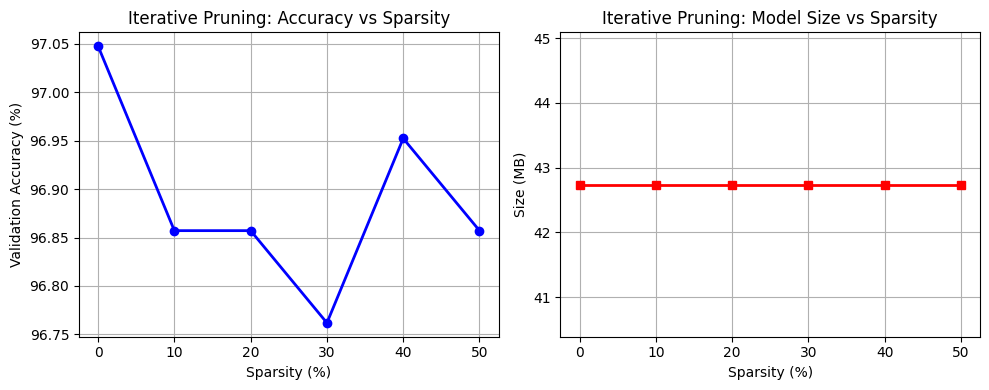

In [52]:
import copy
import os
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from thop import profile

# ---------------------------------------------------------------------------
# 1. Helper Functions
# ---------------------------------------------------------------------------

def evaluate_accuracy(model, loader, device):
    """Calculates validation/test accuracy."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return (correct / total) * 100


def get_model_size_mb(model):
    """Saves a temporary state dict to evaluate physical storage footprint."""
    torch.save(model.state_dict(), "temp_iterative_pruned.pth")
    size_mb = os.path.getsize("temp_iterative_pruned.pth") / (1024 * 1024)
    if os.path.exists("temp_iterative_pruned.pth"):
        os.remove("temp_iterative_pruned.pth")
    return size_mb


def fine_tune_model(model, train_loader, criterion, optimizer, device, epochs=2):
    """Fine-tunes the pruned model for a few epochs per iteration."""
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


# ---------------------------------------------------------------------------
# 2. Iterative Pruning Pipeline
# ---------------------------------------------------------------------------

# Define sparsity targets for each iteration
sparsity_steps = [0.10, 0.20, 0.30, 0.40, 0.50]  # Step-by-step target ratios
EPOCHS_PER_STEP = 2                             # Fine-tuning epochs after each step

print("==================================================")
print("         ITERATIVE PRUNING PIPELINE               ")
print("==================================================")

# Clone the baseline model
iterative_model = copy.deepcopy(model).to(DEVICE)

# Track progress
history = {
    "sparsity": [0.0],
    "accuracy": [evaluate_accuracy(iterative_model, val_loader, DEVICE)],
    "size_mb": [get_model_size_mb(iterative_model)]
}

print(f"Baseline Accuracy : {history['accuracy'][0]:.2f}%")
print(f"Baseline Model Size: {history['size_mb'][0]:.2f} MB\n")

criterion = nn.CrossEntropyLoss()

# ---------------------------------------------------------------------------
# Iterative Loop
# ---------------------------------------------------------------------------
for step_idx, target_sparsity in enumerate(sparsity_steps, start=1):
    pct = int(target_sparsity * 100)
    print(f"--- Iteration {step_idx}/{len(sparsity_steps)}: Target Sparsity = {pct}% ---")

    # 1. Apply L1 Unstructured Pruning to target sparsity level
    for name, module in iterative_model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            # If a mask already exists from previous iteration, remove it to re-prune
            if prune.is_pruned(module):
                prune.remove(module, "weight")
            
            prune.l1_unstructured(module, name="weight", amount=target_sparsity)

    # Make zeroed weights permanent for evaluation/training
    for name, module in iterative_model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            prune.remove(module, "weight")

    acc_post_prune = evaluate_accuracy(iterative_model, val_loader, DEVICE)
    print(f"  Acc immediately after pruning : {acc_post_prune:.2f}%")

    # 2. Fine-tune for a few epochs to recover accuracy
    optimizer = torch.optim.Adam(iterative_model.parameters(), lr=1e-5)
    print(f"  Fine-tuning for {EPOCHS_PER_STEP} epoch(s)...")
    fine_tune_model(
        iterative_model, train_loader, criterion, optimizer, DEVICE, epochs=EPOCHS_PER_STEP
    )

    # 3. Evaluate and log metrics
    acc_post_ft = evaluate_accuracy(iterative_model, val_loader, DEVICE)
    size_mb = get_model_size_mb(iterative_model)

    history["sparsity"].append(target_sparsity)
    history["accuracy"].append(acc_post_ft)
    history["size_mb"].append(size_mb)

    print(f"  Acc after fine-tuning          : {acc_post_ft:.2f}% (Recovery: {acc_post_ft - acc_post_prune:+.2f}%)\n")

# Save final iteratively pruned model
final_pct = int(sparsity_steps[-1] * 100)
save_path = f"resnet18_iterative_pruned_{final_pct}pct.pth"
torch.save(iterative_model, save_path)

print("==================================================")
print(f"Iterative Pruning Complete! Saved model to: {save_path}")
print(f"Final Sparsity : {final_pct}%")
print(f"Final Accuracy : {history['accuracy'][-1]:.2f}%")
print("==================================================")

# ---------------------------------------------------------------------------
# 3. Plotting Iterative Progress
# ---------------------------------------------------------------------------
sparsities_pct = [s * 100 for s in history["sparsity"]]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(sparsities_pct, history["accuracy"], marker="o", color="b", linewidth=2)
plt.title("Iterative Pruning: Accuracy vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Validation Accuracy (%)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(sparsities_pct, history["size_mb"], marker="s", color="r", linewidth=2)
plt.title("Iterative Pruning: Model Size vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Size (MB)")
plt.grid(True)

plt.tight_layout()
plt.show()

         ITERATIVE PRUNING PIPELINE               
Baseline Accuracy : 96.57%
Baseline Model Size: 42.74 MB
Baseline GFLOPs    : 3.6471
Baseline Latency   : 3.84 ms

--- Iteration 1/5: Target Sparsity = 10% ---
  Acc immediately after pruning : 96.86%
  Fine-tuning for 2 epoch(s)...
  [Iteration 1 Results]
  ├── Accuracy : 96.57% (Recovery: -0.29%)
  ├── Size     : 42.74 MB
  ├── GFLOPs   : 3.6471
  └── Latency  : 3.84 ms

--- Iteration 2/5: Target Sparsity = 20% ---
  Acc immediately after pruning : 96.76%
  Fine-tuning for 2 epoch(s)...
  [Iteration 2 Results]
  ├── Accuracy : 97.14% (Recovery: +0.38%)
  ├── Size     : 42.74 MB
  ├── GFLOPs   : 3.6471
  └── Latency  : 3.85 ms

--- Iteration 3/5: Target Sparsity = 30% ---
  Acc immediately after pruning : 96.86%
  Fine-tuning for 2 epoch(s)...
  [Iteration 3 Results]
  ├── Accuracy : 96.67% (Recovery: -0.19%)
  ├── Size     : 42.74 MB
  ├── GFLOPs   : 3.6471
  └── Latency  : 3.84 ms

--- Iteration 4/5: Target Sparsity = 40% ---
  Acc 

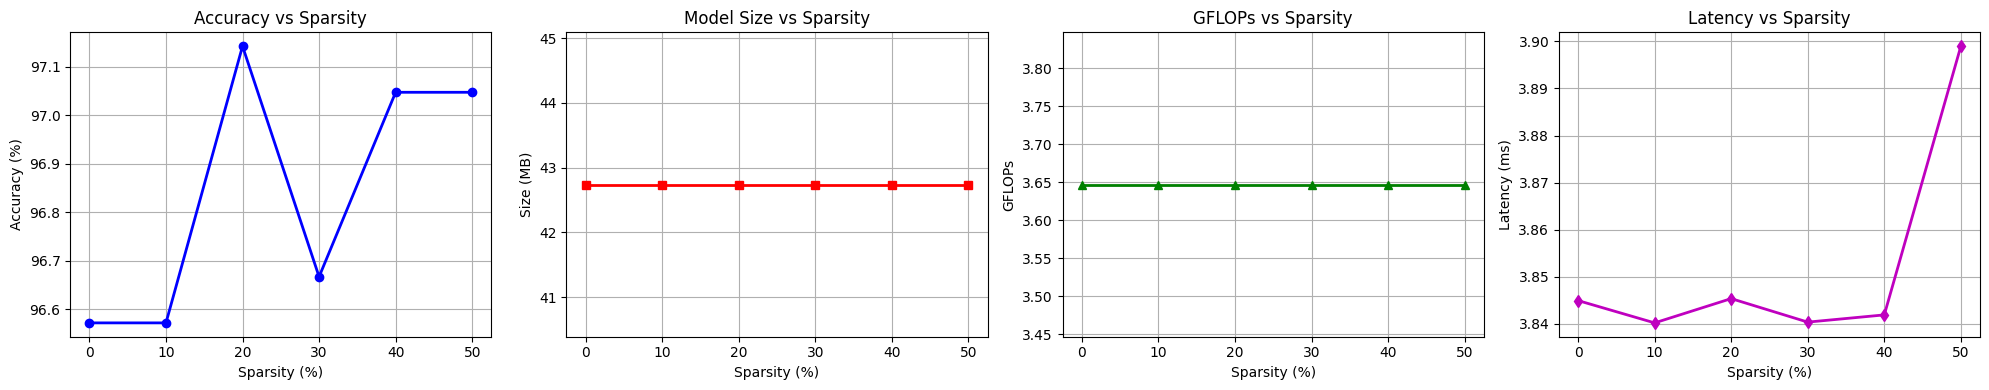

In [53]:
import copy
import os
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from thop import profile

# ---------------------------------------------------------------------------
# 1. Helper Functions
# ---------------------------------------------------------------------------

def evaluate_accuracy(model, loader, device):
    """Calculates validation/test accuracy."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return (correct / total) * 100


def get_model_size_mb(model):
    """Saves a temporary state dict to evaluate physical storage footprint."""
    torch.save(model.state_dict(), "temp_iterative_pruned.pth")
    size_mb = os.path.getsize("temp_iterative_pruned.pth") / (1024 * 1024)
    if os.path.exists("temp_iterative_pruned.pth"):
        os.remove("temp_iterative_pruned.pth")
    return size_mb


def get_gflops_and_latency(model, loader, device, num_images=100):
    """Measures physical computational cost (GFLOPs) and true hardware latency."""
    model.eval()
    images, _ = next(iter(loader))
    real_input = images[0:1].to(device)

    # 1. Compute GFLOPs on a deepcopy to avoid attaching thop hooks to the model
    temp_model = copy.deepcopy(model)
    macs, _ = profile(temp_model, inputs=(real_input,), verbose=False)
    gflops = (macs * 2) / 1e9
    del temp_model

    # 2. Compute Latency
    latency_images = [images[i : i + 1].to(device) for i in range(min(num_images, images.size(0)))]

    # Warmup
    with torch.no_grad():
        _ = model(latency_images[0])
    if device.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()
    with torch.no_grad():
        for img in latency_images:
            _ = model(img)
        if device.type == "cuda":
            torch.cuda.synchronize()
    end_time = time.time()

    avg_latency_ms = ((end_time - start_time) / len(latency_images)) * 1000
    return gflops, avg_latency_ms


def fine_tune_model(model, train_loader, criterion, optimizer, device, epochs=2):
    """Fine-tunes the pruned model for a few epochs per iteration."""
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


# ---------------------------------------------------------------------------
# 2. Iterative Pruning Pipeline
# ---------------------------------------------------------------------------

# Define sparsity targets for each iteration
sparsity_steps = [0.10, 0.20, 0.30, 0.40, 0.50]  # Step-by-step target ratios
EPOCHS_PER_STEP = 2                             # Fine-tuning epochs after each step

print("==================================================")
print("         ITERATIVE PRUNING PIPELINE               ")
print("==================================================")

# Clone the baseline model
iterative_model = copy.deepcopy(model).to(DEVICE)

# Calculate baseline metrics
base_gflops, base_latency = get_gflops_and_latency(iterative_model, test_loader, DEVICE)
base_acc = evaluate_accuracy(iterative_model, val_loader, DEVICE)
base_size = get_model_size_mb(iterative_model)

# Track progress across iterations
history = {
    "sparsity": [0.0],
    "accuracy": [base_acc],
    "size_mb": [base_size],
    "gflops": [base_gflops],
    "latency_ms": [base_latency],
}

print(f"Baseline Accuracy : {base_acc:.2f}%")
print(f"Baseline Model Size: {base_size:.2f} MB")
print(f"Baseline GFLOPs    : {base_gflops:.4f}")
print(f"Baseline Latency   : {base_latency:.2f} ms\n")

criterion = nn.CrossEntropyLoss()

# ---------------------------------------------------------------------------
# Iterative Loop
# ---------------------------------------------------------------------------
for step_idx, target_sparsity in enumerate(sparsity_steps, start=1):
    pct = int(target_sparsity * 100)
    print(f"--- Iteration {step_idx}/{len(sparsity_steps)}: Target Sparsity = {pct}% ---")

    # 1. Apply L1 Unstructured Pruning to target sparsity level
    for name, module in iterative_model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            if prune.is_pruned(module):
                prune.remove(module, "weight")
            
            prune.l1_unstructured(module, name="weight", amount=target_sparsity)

    # Make zeroed weights permanent
    for name, module in iterative_model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            prune.remove(module, "weight")

    acc_post_prune = evaluate_accuracy(iterative_model, val_loader, DEVICE)
    print(f"  Acc immediately after pruning : {acc_post_prune:.2f}%")

    # 2. Fine-tune for a few epochs to recover accuracy
    optimizer = torch.optim.Adam(iterative_model.parameters(), lr=1e-5)
    print(f"  Fine-tuning for {EPOCHS_PER_STEP} epoch(s)...")
    fine_tune_model(
        iterative_model, train_loader, criterion, optimizer, DEVICE, epochs=EPOCHS_PER_STEP
    )

    # 3. Evaluate and log all metrics
    acc_post_ft = evaluate_accuracy(iterative_model, val_loader, DEVICE)
    size_mb = get_model_size_mb(iterative_model)
    gflops, latency_ms = get_gflops_and_latency(iterative_model, test_loader, DEVICE)

    history["sparsity"].append(target_sparsity)
    history["accuracy"].append(acc_post_ft)
    history["size_mb"].append(size_mb)
    history["gflops"].append(gflops)
    history["latency_ms"].append(latency_ms)

    print(f"  [Iteration {step_idx} Results]")
    print(f"  ├── Accuracy : {acc_post_ft:.2f}% (Recovery: {acc_post_ft - acc_post_prune:+.2f}%)")
    print(f"  ├── Size     : {size_mb:.2f} MB")
    print(f"  ├── GFLOPs   : {gflops:.4f}")
    print(f"  └── Latency  : {latency_ms:.2f} ms\n")

# Save final iteratively pruned model
final_pct = int(sparsity_steps[-1] * 100)
save_path = f"resnet18_iterative_pruned_{final_pct}pct.pth"
torch.save(iterative_model, save_path)

print("==================================================")
print(f"Iterative Pruning Complete! Saved model to: {save_path}")
print(f"Final Sparsity : {final_pct}%")
print(f"Final Accuracy : {history['accuracy'][-1]:.2f}%")
print(f"Final Size     : {history['size_mb'][-1]:.2f} MB")
print(f"Final GFLOPs   : {history['gflops'][-1]:.4f}")
print(f"Final Latency  : {history['latency_ms'][-1]:.2f} ms")
print("==================================================")

# ---------------------------------------------------------------------------
# 3. Plotting Iterative Metrics
# ---------------------------------------------------------------------------
sparsities_pct = [s * 100 for s in history["sparsity"]]

plt.figure(figsize=(20, 4))

# Plot 1: Accuracy vs Sparsity
plt.subplot(1, 4, 1)
plt.plot(sparsities_pct, history["accuracy"], marker="o", color="b", linewidth=2)
plt.title("Accuracy vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.grid(True)

# Plot 2: Model Size vs Sparsity
plt.subplot(1, 4, 2)
plt.plot(sparsities_pct, history["size_mb"], marker="s", color="r", linewidth=2)
plt.title("Model Size vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Size (MB)")
plt.grid(True)

# Plot 3: GFLOPs vs Sparsity
plt.subplot(1, 4, 3)
plt.plot(sparsities_pct, history["gflops"], marker="^", color="g", linewidth=2)
plt.title("GFLOPs vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("GFLOPs")
plt.grid(True)

# Plot 4: Latency vs Sparsity
plt.subplot(1, 4, 4)
plt.plot(sparsities_pct, history["latency_ms"], marker="d", color="m", linewidth=2)
plt.title("Latency vs Sparsity")
plt.xlabel("Sparsity (%)")
plt.ylabel("Latency (ms)")
plt.grid(True)

plt.tight_layout()
plt.show()

### Implementing the Efficient-net-B0

In [54]:
import torch
import torch.nn as nn
from torchvision import models

# Load pre-trained EfficientNet-B0
effnet_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Replace the linear head for 10 classes
in_features = effnet_model.classifier[1].in_features
effnet_model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

# Move to GPU
effnet_model = effnet_model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


In [55]:
import copy
import time
import os
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score

# Loss, Optimizer & Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(effnet_model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        pbar.set_description(f"Loss: {loss.item():.4f}")
        
    return running_loss / total, 100.0 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    total = len(all_labels)
    acc = accuracy_score(all_labels, all_preds) * 100.0
    f1 = f1_score(all_labels, all_preds, average="weighted")
    loss = running_loss / total
    
    return loss, acc, f1

# Execute Training Loop
EPOCHS = 20
best_val_acc = 0.0
best_model_weights = copy.deepcopy(effnet_model.state_dict())

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc = train_one_epoch(effnet_model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_f1 = validate(effnet_model, val_loader, criterion, DEVICE)
    
    scheduler.step(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(effnet_model.state_dict())
        
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}% | Val F1: {val_f1:.4f}")

# Load best weights
effnet_model.load_state_dict(best_model_weights)
torch.save(effnet_model.state_dict(), "efficientnet_b0_best.pth")


Epoch 1/20


Training:   0%|          | 0/307 [00:00<?, ?it/s]

Train Loss: 0.9875 | Train Acc: 71.94%
Val Loss:   0.2365 | Val Acc:   92.67% | Val F1: 0.9264

Epoch 2/20


Training:   0%|          | 0/307 [00:00<?, ?it/s]

Train Loss: 0.2929 | Train Acc: 90.55%
Val Loss:   0.1560 | Val Acc:   94.67% | Val F1: 0.9465

Epoch 3/20


...

Train Loss: 0.0427 | Train Acc: 98.16%
Val Loss:   0.0960 | Val Acc:   97.52% | Val F1: 0.9753

Epoch 19/20


Training:   0%|          | 0/307 [00:00<?, ?it/s]

Train Loss: 0.0367 | Train Acc: 98.33%
Val Loss:   0.0845 | Val Acc:   97.81% | Val F1: 0.9782

Epoch 20/20


Training:   0%|          | 0/307 [00:00<?, ?it/s]

Train Loss: 0.0416 | Train Acc: 98.24%
Val Loss:   0.0915 | Val Acc:   97.24% | Val F1: 0.9727


In [56]:
from thop import profile

# 1. Model Size (MB on disk / parameters)
def get_model_size_mb(filepath):
    return os.path.getsize(filepath) / (1024 * 1024)

model_size_mb = get_model_size_mb("efficientnet_b0_best.pth")
total_params = sum(p.numel() for p in effnet_model.parameters())

# 2. GFLOPs calculation using THOP
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)
macs, _ = profile(effnet_model, inputs=(dummy_input,), verbose=False)
gflops = (macs * 2) / 1e9  # 1 MAC ≈ 2 FLOPs

# 3. Test Set Accuracy & Weighted F1 Score
test_loss, test_acc, test_f1 = validate(effnet_model, test_loader, criterion, DEVICE)

# 4. GPU Inference Latency Measurement
effnet_model.eval()

# GPU Warm-up runs
with torch.no_grad():
    for _ in range(50):
        _ = effnet_model(dummy_input)

# Measure average latency over 100 runs
torch.cuda.synchronize()
start_time = time.perf_counter()

with torch.no_grad():
    for _ in range(100):
        _ = effnet_model(dummy_input)
        
torch.cuda.synchronize()
end_time = time.perf_counter()

avg_latency_ms = ((end_time - start_time) / 100) * 1000

# --- Print Summary ---
print("=" * 45)
print("     EFFICIENTNET-B0 BASELINE METRICS     ")
print("=" * 45)
print(f"Parameters       : {total_params:,}")
print(f"Model Size (.pth): {model_size_mb:.2f} MB")
print(f"GFLOPs           : {gflops:.4f} GFLOPs")
print(f"Test Accuracy    : {test_acc:.2f}%")
print(f"Test F1 Score    : {test_f1:.4f}")
print(f"GPU Latency      : {avg_latency_ms:.3f} ms / image")
print("=" * 45)

     EFFICIENTNET-B0 BASELINE METRICS     
Parameters       : 4,020,358
Model Size (.pth): 15.63 MB
GFLOPs           : 0.8278 GFLOPs
Test Accuracy    : 97.33%
Test F1 Score    : 0.9737
GPU Latency      : 8.394 ms / image


##### APPLYING FILTER-PRUNING FOR THE EFFICIENT-NET-B0 MODEL

In [60]:
import copy
import os
import time
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from thop import profile
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

# --- 1. Helper Evaluation Function ---
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    total = len(all_labels)
    acc = accuracy_score(all_labels, all_preds) * 100.0
    f1 = f1_score(all_labels, all_preds, average="weighted")
    return acc, f1

# --- 2. Helper Metrics Function (GFLOPs & Latency) ---
def compute_metrics(model, device, dummy_input):
    model.eval()
    
    # GFLOPs calculation via THOP
    macs, _ = profile(model, inputs=(dummy_input,), verbose=False)
    gflops = (macs * 2) / 1e9  # 1 MAC ≈ 2 FLOPs
    
    # GPU Latency Measurement
    with torch.no_grad():
        for _ in range(30):  # Warmup
            _ = model(dummy_input)
            
    torch.cuda.synchronize()
    start_time = time.perf_counter()
    with torch.no_grad():
        for _ in range(100):
            _ = model(dummy_input)
    torch.cuda.synchronize()
    end_time = time.perf_counter()
    
    avg_latency_ms = ((end_time - start_time) / 100) * 1000
    return gflops, avg_latency_ms

# --- 3. Filter Pruning Function ---
def apply_filter_pruning(model, sparsity):
    """
    Applies structured (L1-norm) filter pruning across all Conv2d layers.
    """
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            # Prune channels along dimension 0 (output channels) using L1 norm
            prune.ln_structured(module, name="weight", amount=sparsity, n=1, dim=0)
            # Make pruning permanent by removing the reparameterization buffer
            prune.remove(module, "weight")
    return model

# --- 4. Fine-Tuning Loop ---
def fine_tune(model, train_loader, val_loader, criterion, optimizer, epochs=3, device=DEVICE):
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

# --- 5. Main Execution: Pruning Loop from Sparsity 0.1 to 0.2 ---
SPARSITIES = [0.10, 0.15, 0.20]
FINE_TUNE_EPOCHS = 3
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)

print("=" * 70)
print(f"{'Sparsity':<10} | {'Test Acc (%)':<12} | {'F1 Score':<10} | {'Model Size':<12} | {'GFLOPs':<10} | {'Latency (ms)':<12}")
print("=" * 70)

for sparsity in SPARSITIES:
    # 1. Load fresh original model state
    pruned_model = copy.deepcopy(effnet_model)
    
    # 2. Apply Filter Pruning
    pruned_model = apply_filter_pruning(pruned_model, sparsity)
    
    # 3. Fine-tune pruned model
    optimizer = torch.optim.Adam(pruned_model.parameters(), lr=1e-5)
    fine_tune(pruned_model, train_loader, val_loader, criterion, optimizer, epochs=FINE_TUNE_EPOCHS, device=DEVICE)
    
    # 4. Save fine-tuned pruned model
    save_path = f"efficientnet_b0_pruned_{int(sparsity*100)}pct.pth"
    torch.save(pruned_model.state_dict(), save_path)
    
    # 5. Calculate Metrics
    test_acc, test_f1 = evaluate_model(pruned_model, test_loader, criterion, DEVICE)
    model_size_mb = os.path.getsize(save_path) / (1024 * 1024)
    gflops, latency_ms = compute_metrics(pruned_model, DEVICE, dummy_input)
    
    # 6. Display Results
    print(f"{sparsity*100:.0f}%{'':<7} | {test_acc:<12.2f} | {test_f1:<10.4f} | {model_size_mb:.2f} MB{'':<4} | {gflops:<10.4f} | {latency_ms:.3f} ms")

print("=" * 70)

Sparsity   | Test Acc (%) | F1 Score   | Model Size   | GFLOPs     | Latency (ms)
10%        | 96.86        | 0.9689     | 15.73 MB     | 0.8278     | 7.843 ms
15%        | 95.81        | 0.9586     | 15.73 MB     | 0.8278     | 8.260 ms
20%        | 95.14        | 0.9519     | 15.73 MB     | 0.8278     | 8.312 ms


In [61]:
import copy
import os
import time
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from thop import profile
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

def evaluate_model(model, loader, criterion, device=DEVICE):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    total = len(all_labels)
    acc = accuracy_score(all_labels, all_preds) * 100.0
    f1 = f1_score(all_labels, all_preds, average="weighted")
    return acc, f1

def compute_metrics(model, device=DEVICE):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    
    # 1. GFLOPs via THOP
    macs, _ = profile(model, inputs=(dummy_input,), verbose=False)
    gflops = (macs * 2) / 1e9  # 1 MAC ≈ 2 FLOPs
    
    # 2. GPU Latency
    with torch.no_grad():
        for _ in range(30):  # Warm-up
            _ = model(dummy_input)
            
    torch.cuda.synchronize()
    start_time = time.perf_counter()
    with torch.no_grad():
        for _ in range(100):
            _ = model(dummy_input)
    torch.cuda.synchronize()
    end_time = time.perf_counter()
    
    avg_latency_ms = ((end_time - start_time) / 100) * 1000
    return gflops, avg_latency_ms

def fine_tune(model, train_loader, val_loader, criterion, epochs=3, lr=1e-5, device=DEVICE):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

In [63]:
def apply_oneshot_pruning(model, target_sparsity=0.20):
    """Prunes target_sparsity percentage of parameters in a single step per layer."""
    pruned_model = copy.deepcopy(model)
    
    for name, module in pruned_model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            prune.l1_unstructured(module, name="weight", amount=target_sparsity)
            prune.remove(module, "weight")
            
    return pruned_model

# --- Run One-Shot Pruning ---
print("=== Starting One-Shot Pruning ===")
oneshot_model = apply_oneshot_pruning(effnet_model, target_sparsity=0.20)

# Fine-tune once
fine_tune(oneshot_model, train_loader, val_loader, criterion, epochs=3)

# Save & Evaluate
torch.save(oneshot_model.state_dict(), "effnet_oneshot_pruned.pth")
acc, f1 = evaluate_model(oneshot_model, test_loader, criterion)
gflops, latency = compute_metrics(oneshot_model)
size_mb = os.path.getsize("effnet_oneshot_pruned.pth") / (1024 * 1024)

print(f"One-Shot Pruned (20% Target) | Acc: {acc:.2f}% | F1: {f1:.4f} | Size: {size_mb:.2f} MB | GFLOPs: {gflops:.4f} | Latency: {latency:.3f} ms")

=== Starting One-Shot Pruning ===
One-Shot Pruned (20% Target) | Acc: 97.43% | F1: 0.9745 | Size: 15.73 MB | GFLOPs: 0.8278 | Latency: 8.016 ms
